# Football Transfer Fee Prediction Pipeline

This notebook implements a clean, production-oriented version of the transfer fee prediction model. It includes data extraction, sophisticated feature engineering (including FIFA ratings integration), and model evaluation using both Linear Regression and Random Forest Regressor.

## 1. Environment Setup and Data Loading

In [48]:
!pip install fuzzywuzzy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\thoma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [49]:
import numpy as np
import pandas as pd
import os
import zipfile
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from fuzzywuzzy import process

# Constants
TRANSFERS_PATH = '../data/transfers.zip'
RATINGS_PATH = '../data/ratings.zip'

def normalize_text(s):
    if not isinstance(s, str): return s
    return unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('utf-8')

transfers = pd.read_csv(TRANSFERS_PATH, compression='zip')
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


## 2. Initial Data Cleaning

We clean the seasons, normalize positions, and remove inconsistent rows (e.g., Age 0).

In [50]:
transfers['Season_transferred']=transfers['Season'].str.split('-').str[0]
transfers = transfers.astype({'Season_transferred':'int64'})
transfers = transfers.drop(columns =['Season'])
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Market_value,Transfer_fee,Season_transferred
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,NaN,60000000,2000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,NaN,56810000,2000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,NaN,40000000,2000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,NaN,36150000,2000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,NaN,34500000,2000


In [51]:
print(transfers.Position.unique())
transfers.Position = transfers.Position.replace(to_replace=['Second Striker','Centre-Forward','Sweeper'],value = ['Forward','Forward','Defender'])
print(transfers.Position.unique())

<ArrowStringArray>
[      'Right Winger',     'Centre-Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',     'Second Striker',         'Goalkeeper',
         'Right-Back',      'Left Midfield',          'Left-Back',
     'Right Midfield',            'Forward',            'Sweeper',
           'Defender',         'Midfielder']
Length: 17, dtype: str
<ArrowStringArray>
[      'Right Winger',            'Forward',        'Left Winger',
        'Centre-Back',   'Central Midfield', 'Attacking Midfield',
 'Defensive Midfield',         'Goalkeeper',         'Right-Back',
      'Left Midfield',          'Left-Back',     'Right Midfield',
           'Defender',         'Midfielder']
Length: 14, dtype: str


In [52]:
transfers.Age.unique()
transfers_weird = transfers.loc[transfers.Age == 0]
print(transfers_weird)

                  Name Position  Age Team_from    League_from  Team_to  \
236  Marzouq Al-Otaibi  Forward    0    Shabab   Saudi Arabia  Ittihad   

         League_to  Market_value  Transfer_fee  Season_transferred  
236   Saudi Arabia           NaN       2000000                2000  


In [53]:
transfers_midfield = transfers.loc[transfers.Position == 'Midfielder']
print(transfers_midfield.head(20))
transfers_defenders = transfers.loc[transfers.Position =='Defender']
print(transfers_defenders.head(20))

             Name    Position  Age Team_from     League_from Team_to  \
705  Tony Dinning  Midfielder   27    Wolves  First Division   Wigan   

                       League_to  Market_value  Transfer_fee  \
705  Second Division (bis 03/04)           NaN       1130000   

     Season_transferred  
705                2002  
                Name  Position  Age      Team_from     League_from  \
471    Thomas Hengen  Defender   26  VfL Wolfsburg    1.Bundesliga   
652  Sergio Hellings  Defender   17       Ajax U19  U19 Eredivisie   

            Team_to     League_to  Market_value  Transfer_fee  \
471  1.FC K'lautern  1.Bundesliga           NaN       2250000   
652  Anderlecht U19       Belgium           NaN       2000000   

     Season_transferred  
471                2001  
652                2002  


In [54]:
transfers_cleaned= transfers[~((transfers.Position=='Midfielder')|(transfers.Position=='Defender')|(transfers.Age ==0))]
transfers_cleaned['Transfer_fee_in_mln']=transfers_cleaned['Transfer_fee']/1000000
transfers_cleaned['Market_value_in_mln']=transfers_cleaned['Market_value']/1000000
transfers_cleaned = transfers_cleaned.drop(labels = ['Transfer_fee','Market_value'],axis = 1)
pd.to_datetime(transfers_cleaned['Season_transferred'],format ='%Y')
transfers_cleaned.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000,60.00,NaN
1,Hernán Crespo,Forward,25,Parma,Serie A,Lazio,Serie A,2000,56.81,NaN
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000,40.00,NaN
3,Gabriel Batistuta,Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000,36.15,NaN
4,Nicolas Anelka,Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000,34.50,NaN


In [55]:
season_fee_stats = (
    transfers_cleaned
    .groupby('Season_transferred')['Transfer_fee_in_mln']
    .agg(mean_transfer_fee='mean', median_transfer_fee='median')
    .reset_index()
) #saving aggregate stats if called back later

## 3. Feature Engineering: Basic Features

Extracting Lastnames and normalizing text for reliable merging.

In [56]:
transfers_2015_18 = transfers_cleaned[transfers_cleaned['Season_transferred'] > 2014].copy()
transfers_2015_18['Lastname'] = transfers_2015_18['Name'].apply(lambda x: x.split(' ')[-1])

for col in ['Lastname', 'Team_from', 'Team_to']:
    transfers_2015_18[col] = transfers_2015_18[col].apply(normalize_text)

transfers_2015_18.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,Lastname
3713,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,Bruyne
3714,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,Sterling
3715,Ángel Di María,Right Winger,27,Man Utd,Premier League,Paris SG,Ligue 1,2015,63.0,50.0,Maria
3716,Anthony Martial,Left Winger,19,Monaco,Ligue 1,Man Utd,Premier League,2015,60.0,8.0,Martial
3717,Alex Teixeira,Attacking Midfield,26,Shakhtar D.,Premier Liga,JS Suning,Super League,2015,50.0,30.0,Teixeira


In [57]:
import zipfile

ratings_zip_path = '../data/ratings.zip'
with zipfile.ZipFile(ratings_zip_path) as zf:
    fifa_full_15 = pd.read_csv(zf.open('players_15.csv'))
    fifa_full_16 = pd.read_csv(zf.open('players_16.csv'))
    fifa_full_17 = pd.read_csv(zf.open('players_17.csv'))
    fifa_full_18 = pd.read_csv(zf.open('players_18.csv'))

fifa_full_15['Season'] = 2015
fifa_full_16['Season'] = 2016
fifa_full_17['Season'] = 2017
fifa_full_18['Season'] = 2018

# Quick schema inspection
print("Shapes:")
print("2015:", fifa_full_15.shape, "2016:", fifa_full_16.shape, "2017:", fifa_full_17.shape, "2018:", fifa_full_18.shape)

print("\nColumn count by year:")
print(len(fifa_full_15.columns), len(fifa_full_16.columns), len(fifa_full_17.columns), len(fifa_full_18.columns))

print("\nDo all years have identical columns?",
      set(fifa_full_15.columns) == set(fifa_full_16.columns) == set(fifa_full_17.columns) == set(fifa_full_18.columns))

# Merge full datasets for broader inspection
fifas_full_merged = pd.concat([fifa_full_15, fifa_full_16, fifa_full_17, fifa_full_18], ignore_index=True, sort=False)

print("\nMerged full dataset shape:", fifas_full_merged.shape)
print("\nFirst 50 columns:")
print(fifas_full_merged.columns[:50].tolist())

fifas_full_merged.head()
fifas_full_merged.sample(5, random_state=42)

Shapes:
2015: (15465, 105) 2016: (14881, 105) 2017: (17009, 105) 2018: (17592, 105)

Column count by year:
105 105 105 105

Do all years have identical columns? True

Merged full dataset shape: (64947, 105)

First 50 columns:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribb

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,Season
52569,192890,https://sofifa.com/player/192890/erbin-trejo/1...,E. Trejo,Erbín Trejo,27,1990-06-03,171,69,Mexico,Querétaro,...,66+1,66+1,66+1,67+1,66+1,62+1,62+1,62+1,66+1,2018
35671,194730,https://sofifa.com/player/194730/juan-carlos-m...,Juan Carlos,Juan Carlos Martín Corral,28,1988-01-20,187,82,Spain,Elche CF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
273,152554,https://sofifa.com/player/152554/gael-clichy/1...,G. Clichy,Gaël Clichy,28,1985-07-26,176,65,France,Manchester City,...,75+1,75+1,75+1,80+1,79+1,76+1,76+1,76+1,79+1,2015
16234,188942,https://sofifa.com/player/188942/victor-wanyam...,V. Wanyama,Victor Wanyama,24,1991-06-25,188,76,Kenya,Southampton,...,77+0,77+0,77+0,75+0,75+0,80+0,80+0,80+0,75+0,2016
20660,206018,https://sofifa.com/player/206018/igor-vetokele...,I. Vetokele,Igor Vetokele,23,1992-03-23,173,74,Angola,Charlton Athletic,...,45+0,45+0,45+0,50+0,47+0,42+0,42+0,42+0,47+0,2016


## 4. Advanced Feature Engineering: FIFA Ratings Integration

We load FIFA player ratings (Overall/Potential) and use multiple fallback strategies to recover missing metadata like Nationality.

In [58]:
nat_frames = []
with zipfile.ZipFile(RATINGS_PATH) as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr-2000}.csv'))
        nat_col = 'nationality_name' if 'nationality_name' in f.columns else ('nationality' if 'nationality' in f.columns else None)
        if nat_col is None: continue

        mini = f[['short_name', 'club', nat_col, 'overall', 'potential']].copy()
        mini['Lastname'] = mini['short_name'].str.split(' ').str[-1].apply(normalize_text)
        mini['club'] = mini['club'].apply(normalize_text)
        mini['Season_transferred'] = yr
        mini = mini.rename(columns={nat_col: 'Nationality'})
        nat_frames.append(mini)

fifa_nat = pd.concat(nat_frames, ignore_index=True)
fifa_nat['Nationality'] = fifa_nat['Nationality'].apply(normalize_text)

fifa_nat_best_club = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'club', 'Season_transferred'])
fifa_nat_best_name_season = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'Season_transferred'])

print(f'FIFA lookup rows (club-level): {len(fifa_nat_best_club)}')
print(f'FIFA lookup rows (lastname-season): {len(fifa_nat_best_name_season)}')

FIFA lookup rows (club-level): 63797
FIFA lookup rows (lastname-season): 46302


## 5. Dataset Merging and Fallback Recovery

We attempt to match transfers to FIFA data using Team_from, then Team_to, and finally a broader Lastname+Season search.

In [59]:
# Merge on Team_from
transfers_fe = transfers_2015_18.merge(
    fifa_nat_best_club.rename(columns={'club': 'Team_from', 'overall': 'overall_from', 'potential': 'potential_from'}),
    on=['Lastname', 'Team_from', 'Season_transferred'], how='left'
)

# Fallback on Team_to for nulls
null_mask = transfers_fe['overall_from'].isna()
to_lookup = fifa_nat_best_club.rename(columns={'club': 'Team_to', 'overall': 'overall_to', 'potential': 'potential_to', 'Nationality': 'Nat_to'})
transfers_fe = transfers_fe.merge(to_lookup, on=['Lastname', 'Team_to', 'Season_transferred'], how='left')

# Final broader fallback
transfers_fe['overall'] = transfers_fe['overall_from'].combine_first(transfers_fe['overall_to'])
transfers_fe['potential'] = transfers_fe['potential_from'].combine_first(transfers_fe['potential_to'])

final_df = transfers_fe.dropna(subset=['overall']).copy()
print(f"Nationality nulls after fallback: {final_df['Nationality'].isna().sum()} / {len(final_df)}")

Nationality nulls after fallback: 40 / 382


## 6. Engineered Indicators for Bias and Performance

Creating buckets for Age and Position, and purchasing power indicators for leagues and clubs.

In [60]:
#Purchasing power proxy
league_median = final_df.groupby('League_to')['Transfer_fee_in_mln'].median()
final_df['league_median_fee_to'] = final_df['League_to'].map(league_median)

# Seasonal market normalization: account for inflation/deflation across years
# Compute mean transfer fee per season to normalize for market changes over time
season_mean_fee = final_df.groupby('Season_transferred')['Transfer_fee_in_mln'].mean()
final_df['season_mean_fee'] = final_df['Season_transferred'].map(season_mean_fee)
# Create season-normalized fee: transfer fee relative to that year's market average
final_df['fee_relative_to_season'] = final_df['Transfer_fee_in_mln'] / final_df['season_mean_fee']
print(f"Season mean transfer fees:\n{season_mean_fee.round(3)}\n")

# Age buckets
final_df['age_bucket'] = pd.cut(final_df['Age'], bins=[14, 20, 24, 27, 30, 50], labels=['<20', '20-23', '24-26', '27-29', '30+'])

# Position buckets
pos_map = {
    'Centre-Back': 'Defender', 'Right-Back': 'Defender', 'Left-Back': 'Defender',
    'Central Midfield': 'Midfielder', 'Attacking Midfield': 'Midfielder', 'Defensive Midfield': 'Midfielder',
    'Right Winger': 'Winger', 'Left Winger': 'Winger', 'Forward': 'Forward', 'Goalkeeper': 'Goalkeeper'
}
final_df['pos_group'] = final_df['Position'].map(pos_map).fillna('Other')

final_df.head()

Season mean transfer fees:
Season_transferred
2015    15.936
2016    17.512
2017    22.664
2018    13.582
Name: Transfer_fee_in_mln, dtype: float64



,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,...,Nat_to,overall_to,potential_to,overall,potential,league_median_fee_to,season_mean_fee,fee_relative_to_season,age_bucket,pos_group
0,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,...,NaN,NaN,NaN,81.0,86.0,14.55,15.936458,4.768939,20-23,Midfielder
1,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,...,NaN,NaN,NaN,80.0,86.0,14.55,15.936458,3.997124,<20,Winger
5,Christian Benteke,Forward,24,Aston Villa,Premier League,Liverpool,Premier League,2015,46.5,20.0,...,NaN,NaN,NaN,80.0,85.0,14.55,15.936458,2.917838,20-23,Forward
6,Nicolás Otamendi,Centre-Back,27,Valencia CF,LaLiga,Man City,Premier League,2015,44.6,25.0,...,NaN,NaN,NaN,80.0,84.0,14.55,15.936458,2.798614,24-26,Defender
7,Julian Draxler,Central Midfield,21,FC Schalke 04,1.Bundesliga,VfL Wolfsburg,1.Bundesliga,2015,43.0,22.0,...,NaN,NaN,NaN,80.0,85.0,10.25,15.936458,2.698216,20-23,Midfielder


# Fairness Framework

In [61]:
# Fairness framework for model evaluation
FAIRNESS_FRAMEWORK = {
    'objective': 'Check whether prediction quality and direction of error differ across groups.',
    'target': 'Transfer_fee_in_mln',
    'model_under_evaluation': 'Baseline Random Forest (no engineered FIFA features)',
    'sensitive_or_context_groups': ['League_from', 'Nationality', 'Region'],
    'minimum_group_size': 20,
    'metrics': [
        'Signed residual (mean/median): detect over- vs underprediction by group',
        'MAE and RMSE: compare error magnitude by group',
        'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values',
    ],
    'interpretation_notes': [
        'Negative residual means underprediction (actual fee > predicted fee).',
        'Positive residual means overprediction (actual fee < predicted fee).',
        'Group-level results should be interpreted with sample-size caution.',
    ],
}

for k, v in FAIRNESS_FRAMEWORK.items():
    print(f"{k}: {v}")

objective: Check whether prediction quality and direction of error differ across groups.
target: Transfer_fee_in_mln
model_under_evaluation: Baseline Random Forest (no engineered FIFA features)
sensitive_or_context_groups: ['League_from', 'Nationality', 'Region']
minimum_group_size: 20
metrics: ['Signed residual (mean/median): detect over- vs underprediction by group', 'MAE and RMSE: compare error magnitude by group', 'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values']
interpretation_notes: ['Negative residual means underprediction (actual fee > predicted fee).', 'Positive residual means overprediction (actual fee < predicted fee).', 'Group-level results should be interpreted with sample-size caution.']


In [62]:
# Baseline Model Training + Fairness Intervention Setup
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# Step 1: Prepare baseline data
transfers_baseline = transfers_cleaned.drop(columns=['Name', 'Market_value_in_mln']).copy()
transfers_baseline = pd.get_dummies(transfers_baseline)

y_baseline = transfers_baseline['Transfer_fee_in_mln']
X_baseline = transfers_baseline.drop(columns=['Transfer_fee_in_mln'])

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, random_state=69, test_size=0.3
)

print(f"Training set: {len(X_train_base)} | Test set: {len(X_test_base)}")

# Step 2: Compute fairness-aware weights BEFORE training
print("\n[FAIRNESS] Computing fairness-aware sample weights...")

# Get baseline predictions via cross-validation to estimate residuals
y_train_pred_cv = cross_val_predict(
    RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    X_train_base, y_train_base, cv=3
)
train_residuals_abs = np.abs(y_train_pred_cv - y_train_base.values)

# Group league info for training set (handle one-hot encoding)
league_col_name = [c for c in X_train_base.columns if 'League_from' in c][0] if any('League_from' in c for c in X_train_base.columns) else None

if league_col_name:
    league_mae = pd.DataFrame({
        'league': X_train_base[league_col_name],
        'abs_error': train_residuals_abs
    }).groupby('league')['abs_error'].mean()
    
    # Inverse weighting: high-error groups get higher weight
    max_mae = league_mae.max()
    min_mae = league_mae.min()
    league_weight_factor = 1 + (league_mae - min_mae) / (max_mae - min_mae + 1e-8)
    fairness_weights = X_train_base[league_col_name].map(league_weight_factor).fillna(1.0).values
    fairness_weights = fairness_weights / fairness_weights.mean()  # Normalize
    print(f"  Weight range: [{fairness_weights.min():.3f}, {fairness_weights.max():.3f}]")
else:
    fairness_weights = None
    print("  League column not found in one-hot encoded features, using uniform weights")

# Step 3: Train baseline RF (without fairness weights)
print("\n[BASELINE MODEL] Training Random Forest...")
rfr_baseline = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=169,
    n_jobs=-1
)
rfr_baseline.fit(X_train_base, y_train_base)
y_pred_baseline = rfr_baseline.predict(X_test_base)
y_pred_rfr = y_pred_baseline  # For compatibility

rmse_baseline = np.sqrt(mean_squared_error(y_test_base, y_pred_baseline))
r2_baseline = r2_score(y_test_base, y_pred_baseline)
print(f"  RMSE: {rmse_baseline:.3f} | R²: {r2_baseline:.3f}")

# Step 4: Train fairness-aware RF (with fairness weights)
print("\n[FAIRNESS MODEL] Training fairness-aware Random Forest...")
rfr_fair = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=169,
    n_jobs=-1
)
rfr_fair.fit(X_train_base, y_train_base, sample_weight=fairness_weights)
y_pred_fair = rfr_fair.predict(X_test_base)

rmse_fair = np.sqrt(mean_squared_error(y_test_base, y_pred_fair))
r2_fair = r2_score(y_test_base, y_pred_fair)
print(f"  RMSE: {rmse_fair:.3f} | R²: {r2_fair:.3f}")

print("\n[SUMMARY] Model comparison:")
print(f"  Baseline RMSE: {rmse_baseline:.3f} vs Fair RMSE: {rmse_fair:.3f} (Δ {rmse_fair - rmse_baseline:+.3f})")
print(f"  Baseline R²: {r2_baseline:.3f} vs Fair R²: {r2_fair:.3f} (Δ {r2_fair - r2_baseline:+.3f})")

Training set: 3287 | Test set: 1409

[FAIRNESS] Computing fairness-aware sample weights...
  Weight range: [0.503, 1.007]

[BASELINE MODEL] Training Random Forest...
  RMSE: 8.155 | R²: 0.300

[FAIRNESS MODEL] Training fairness-aware Random Forest...
  RMSE: 8.176 | R²: 0.296

[SUMMARY] Model comparison:
  Baseline RMSE: 8.155 vs Fair RMSE: 8.176 (Δ +0.021)
  Baseline R²: 0.300 vs Fair R²: 0.296 (Δ -0.004)


Evaluation set: 1409 | Nationality coverage: 255/1409

FAIRNESS METRICS BY LEAGUE
                        League   n  Baseline_Bias  Fair_Bias  Baseline_MAE  Fair_MAE  Bias_Reduction  MAE_Improvement
                        Canada   1          9.298      9.094         9.298     9.094           0.204            0.204
              Vysheyshaya Liga   1          9.125      9.194         9.125     9.194          -0.069           -0.069
                         Qatar   2         -5.975     -5.988         7.251     7.235          -0.013            0.015
                      Liga NOS  50         -3.268     -3.311         6.926     6.955          -0.043           -0.030
                        LaLiga 118         -0.028      0.029         6.532     6.578          -0.001           -0.046
                  1.Bundesliga  62         -0.852     -0.873         6.475     6.465          -0.021            0.010
                Premier League 194         -1.544     -1.535         5.944     5.937        

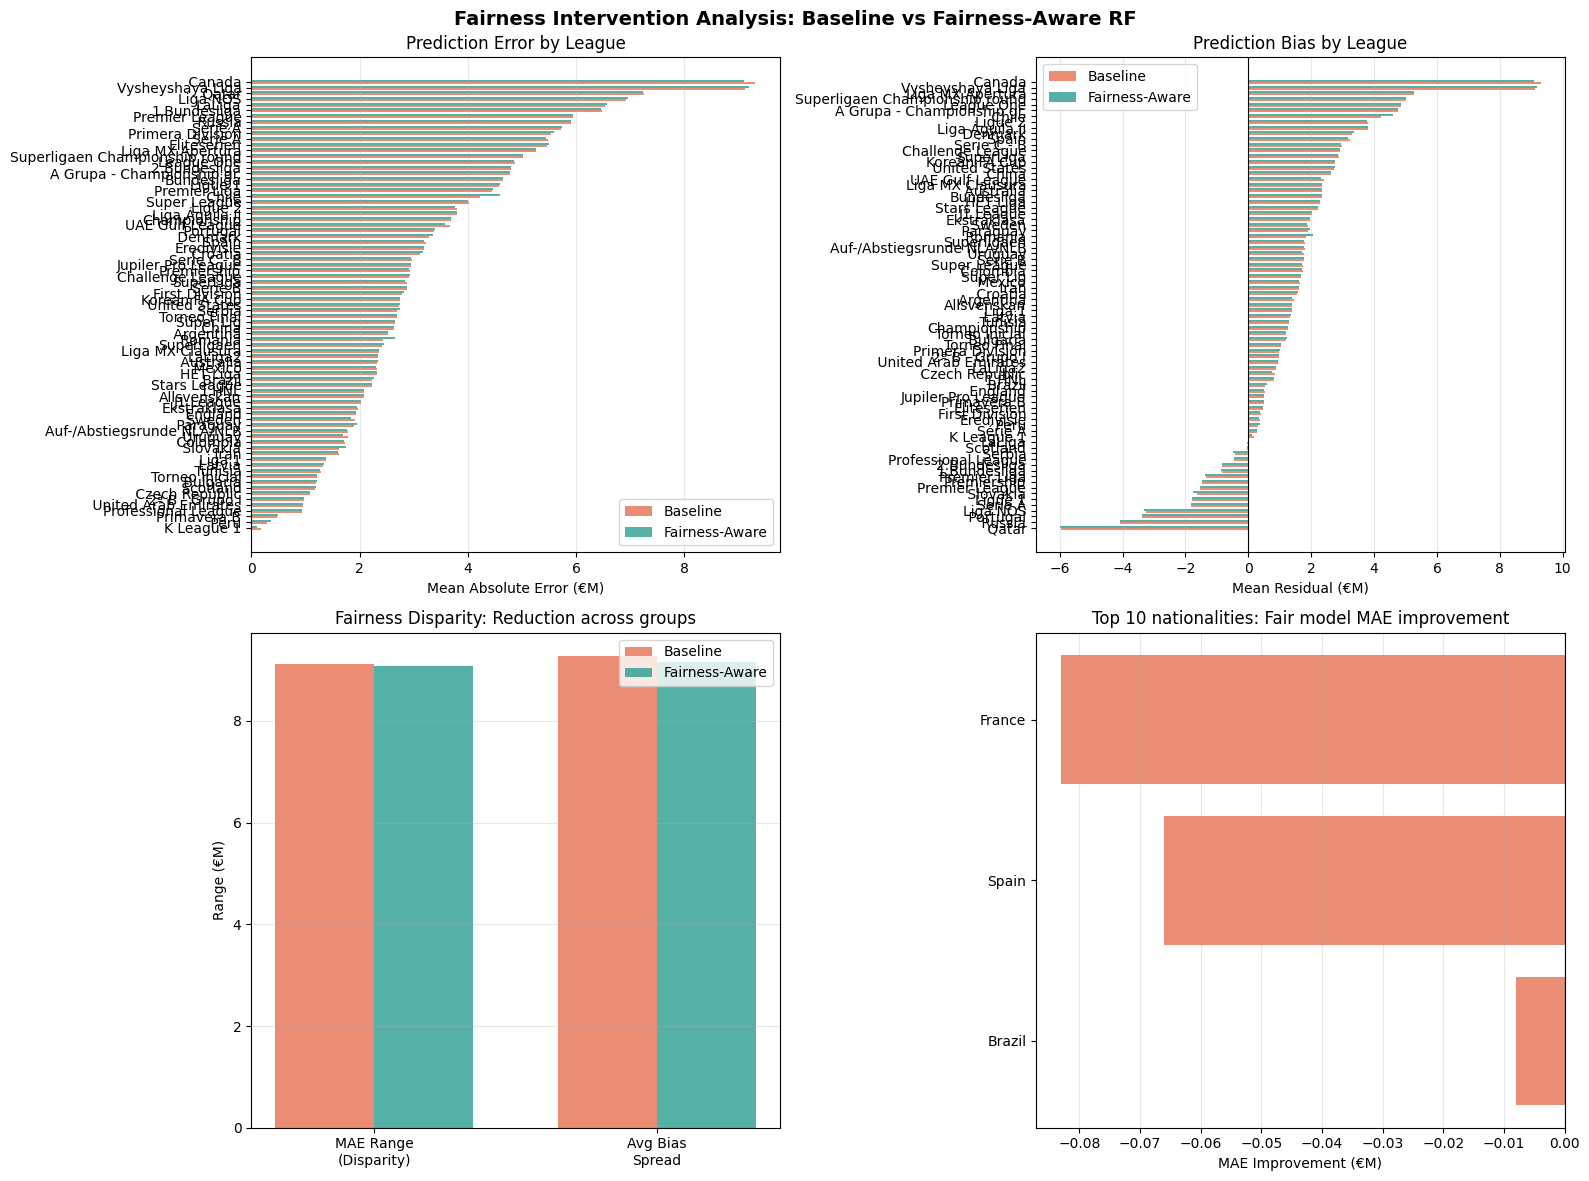


✓ Fairness evaluation complete


In [63]:
# Fairness Evaluation: Disaggregation by League & Nationality
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile

MIN_N = 20

# Prepare evaluation dataframe with original columns
eval_df = transfers_cleaned.loc[X_test_base.index].copy()
eval_df['y_true'] = y_test_base.values
eval_df['y_pred_baseline'] = y_pred_baseline
eval_df['y_pred_fair'] = y_pred_fair

# Compute residuals and errors
eval_df['residual_baseline'] = eval_df['y_pred_baseline'] - eval_df['y_true']
eval_df['residual_fair'] = eval_df['y_pred_fair'] - eval_df['y_true']
eval_df['abs_error_baseline'] = np.abs(eval_df['residual_baseline'])
eval_df['abs_error_fair'] = np.abs(eval_df['residual_fair'])

# Extract nationality information
if 'Lastname' not in eval_df.columns:
    eval_df['Lastname'] = eval_df['Name'].str.split(' ').str[-1]

eval_df['Lastname'] = (
    eval_df['Lastname'].astype(str)
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# Load nationality data from FIFA ratings
_nat_frames = []
with zipfile.ZipFile('../data/ratings.zip') as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr - 2000}.csv'))
        nat_col = next((c for c in ['nationality_name', 'nationality'] if c in f.columns), None)
        if nat_col is None:
            continue
        mini = f[['short_name', nat_col]].copy()
        mini.columns = ['short_name', 'Nationality']
        mini['Lastname'] = (
            mini['short_name'].str.split(' ').str[-1]
            .str.normalize('NFKD')
            .str.encode('ascii', errors='ignore')
            .str.decode('utf-8')
        )
        mini['_season'] = yr
        _nat_frames.append(mini[['Lastname', '_season', 'Nationality']].drop_duplicates())

_nat_lookup = pd.concat(_nat_frames, ignore_index=True).drop_duplicates(subset=['Lastname', '_season'], keep='first')
eval_df['_season'] = eval_df['Season_transferred'].astype(int)
eval_df = eval_df.merge(_nat_lookup, how='left', on=['Lastname', '_season']).drop(columns=['_season'])

# Create region mapping
REGION_MAP = {
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Uruguay': 'South America', 'Chile': 'South America', 'Paraguay': 'South America',
    'Ecuador': 'South America', 'Peru': 'South America', 'Venezuela': 'South America',
    'France': 'W. Europe', 'Spain': 'W. Europe', 'Germany': 'W. Europe',
    'Italy': 'W. Europe', 'Portugal': 'W. Europe', 'Netherlands': 'W. Europe',
    'Belgium': 'W. Europe', 'England': 'W. Europe', 'Switzerland': 'W. Europe',
    'Austria': 'W. Europe', 'Scotland': 'W. Europe', 'Wales': 'W. Europe',
    'Republic of Ireland': 'W. Europe', 'Denmark': 'W. Europe', 'Sweden': 'W. Europe',
    'Norway': 'W. Europe', 'Finland': 'W. Europe',
    'Poland': 'E. Europe', 'Czech Republic': 'E. Europe', 'Croatia': 'E. Europe',
    'Serbia': 'E. Europe', 'Bosnia Herzegovina': 'E. Europe', 'Romania': 'E. Europe',
    'Hungary': 'E. Europe', 'Slovakia': 'E. Europe', 'Slovenia': 'E. Europe',
    'Bulgaria': 'E. Europe', 'Ukraine': 'E. Europe', 'Russia': 'E. Europe',
    'Greece': 'E. Europe', 'Turkey': 'E. Europe', 'Albania': 'E. Europe',
    'Montenegro': 'E. Europe', 'Georgia': 'E. Europe',
    'Senegal': 'Africa', 'Ivory Coast': 'Africa', 'Côte d\'Ivoire': 'Africa',
    'Ghana': 'Africa', 'Nigeria': 'Africa', 'Cameroon': 'Africa',
    'DR Congo': 'Africa', 'Mali': 'Africa', 'Guinea': 'Africa', 'Gabon': 'Africa',
    'Morocco': 'Africa', 'Algeria': 'Africa', 'Tunisia': 'Africa', 'Egypt': 'Africa',
    'Congo': 'Africa',
    'Mexico': 'Americas (other)', 'United States': 'Americas (other)',
    'Canada': 'Americas (other)', 'Jamaica': 'Americas (other)',
    'Costa Rica': 'Americas (other)', 'Honduras': 'Americas (other)',
    'Japan': 'Asia & Oceania', 'South Korea': 'Asia & Oceania',
    'Australia': 'Asia & Oceania', 'Iran': 'Asia & Oceania',
}
eval_df['Region'] = eval_df['Nationality'].map(REGION_MAP).fillna('Other')

print(f"Evaluation set: {len(eval_df)} | Nationality coverage: {eval_df['Nationality'].notna().sum()}/{len(eval_df)}")

# Fairness analysis by League
print("\n" + "="*80)
print("FAIRNESS METRICS BY LEAGUE")
print("="*80)

league_comparison = pd.DataFrame()
for league in eval_df['League_from'].unique():
    league_mask = eval_df['League_from'] == league
    league_comparison = pd.concat([league_comparison, pd.DataFrame([{
        'League': league,
        'n': league_mask.sum(),
        'Baseline_Bias': eval_df.loc[league_mask, 'residual_baseline'].mean(),
        'Fair_Bias': eval_df.loc[league_mask, 'residual_fair'].mean(),
        'Baseline_MAE': eval_df.loc[league_mask, 'abs_error_baseline'].mean(),
        'Fair_MAE': eval_df.loc[league_mask, 'abs_error_fair'].mean(),
    }])], ignore_index=True)

league_comparison['Bias_Reduction'] = (
    np.abs(league_comparison['Baseline_Bias']) - np.abs(league_comparison['Fair_Bias'])
).round(3)
league_comparison['MAE_Improvement'] = (
    league_comparison['Baseline_MAE'] - league_comparison['Fair_MAE']
).round(3)
league_comparison = league_comparison.sort_values('Baseline_MAE', ascending=False)

print(league_comparison.round(3).to_string(index=False))

# Fairness analysis by Nationality (filtered for n >= MIN_N)
print("\n" + "="*80)
print(f"FAIRNESS METRICS BY NATIONALITY (n >= {MIN_N})")
print("="*80)

nat_comparison = pd.DataFrame()
for nat in eval_df['Nationality'].dropna().unique():
    nat_mask = eval_df['Nationality'] == nat
    if nat_mask.sum() >= MIN_N:
        nat_comparison = pd.concat([nat_comparison, pd.DataFrame([{
            'Nationality': nat,
            'n': nat_mask.sum(),
            'Baseline_MAE': eval_df.loc[nat_mask, 'abs_error_baseline'].mean(),
            'Fair_MAE': eval_df.loc[nat_mask, 'abs_error_fair'].mean(),
            'Baseline_Bias': eval_df.loc[nat_mask, 'residual_baseline'].mean(),
            'Fair_Bias': eval_df.loc[nat_mask, 'residual_fair'].mean(),
        }])], ignore_index=True)

nat_comparison['MAE_Improvement'] = (
    nat_comparison['Baseline_MAE'] - nat_comparison['Fair_MAE']
).round(3)
nat_comparison = nat_comparison.sort_values('Baseline_MAE', ascending=False)

print(f"Nationalities analyzed: {len(nat_comparison)}")
print(nat_comparison.head(15).round(3).to_string(index=False))

# Fairness disparity metrics
print("\n" + "="*80)
print("FAIRNESS DISPARITY SUMMARY (MAE range across leagues)")
print("="*80)

baseline_disparity = league_comparison['Baseline_MAE'].max() - league_comparison['Baseline_MAE'].min()
fair_disparity = league_comparison['Fair_MAE'].max() - league_comparison['Fair_MAE'].min()
disparity_reduction = baseline_disparity - fair_disparity

print(f"Baseline MAE range (disparity):     {baseline_disparity:.3f}")
print(f"Fairness-aware MAE range:           {fair_disparity:.3f}")
print(f"Disparity reduction:                {disparity_reduction:+.3f} ({disparity_reduction/baseline_disparity*100:+.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Fairness Intervention Analysis: Baseline vs Fairness-Aware RF', fontsize=14, fontweight='bold')

# Plot 1: MAE by League
ax = axes[0, 0]
league_sort = league_comparison.sort_values('Baseline_MAE')
x = np.arange(len(league_sort))
width = 0.35
ax.barh(x - width/2, league_sort['Baseline_MAE'], width, label='Baseline', color='#e76f51', alpha=0.8)
ax.barh(x + width/2, league_sort['Fair_MAE'], width, label='Fairness-Aware', color='#2a9d8f', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(league_sort['League'])
ax.set_xlabel('Mean Absolute Error (€M)')
ax.set_title('Prediction Error by League')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 2: Bias by League
ax = axes[0, 1]
league_sort_bias = league_comparison.sort_values('Baseline_Bias')
x = np.arange(len(league_sort_bias))
ax.barh(x - width/2, league_sort_bias['Baseline_Bias'], width, label='Baseline', color='#e76f51', alpha=0.8)
ax.barh(x + width/2, league_sort_bias['Fair_Bias'], width, label='Fairness-Aware', color='#2a9d8f', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(league_sort_bias['League'])
ax.set_xlabel('Mean Residual (€M)')
ax.set_title('Prediction Bias by League')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 3: Disparity comparison
ax = axes[1, 0]
disparity_data = pd.DataFrame({
    'Metric': ['MAE Range\n(Disparity)', 'Avg Bias\nSpread'],
    'Baseline': [baseline_disparity, np.abs(league_comparison['Baseline_Bias']).max() - np.abs(league_comparison['Baseline_Bias']).min()],
    'Fair': [fair_disparity, np.abs(league_comparison['Fair_Bias']).max() - np.abs(league_comparison['Fair_Bias']).min()]
})
x = np.arange(len(disparity_data))
ax.bar(x - width/2, disparity_data['Baseline'], width, label='Baseline', color='#e76f51', alpha=0.8)
ax.bar(x + width/2, disparity_data['Fair'], width, label='Fairness-Aware', color='#2a9d8f', alpha=0.8)
ax.set_ylabel('Range (€M)')
ax.set_title('Fairness Disparity: Reduction across groups')
ax.set_xticks(x)
ax.set_xticklabels(disparity_data['Metric'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 4: Top nationalities MAE improvement
ax = axes[1, 1]
top_nat = nat_comparison.head(10).sort_values('MAE_Improvement', ascending=False)
colors = ['#2a9d8f' if x > 0 else '#e76f51' for x in top_nat['MAE_Improvement']]
ax.barh(range(len(top_nat)), top_nat['MAE_Improvement'], color=colors, alpha=0.8)
ax.set_yticks(range(len(top_nat)))
ax.set_yticklabels(top_nat['Nationality'])
ax.set_xlabel('MAE Improvement (€M)')
ax.set_title('Top 10 nationalities: Fair model MAE improvement')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Fairness evaluation complete")

## 7. Model Training: Linear Regression Baseline

In [64]:
# Drop name-specific identifiers and any FIFA name-like columns that cause leakage
df_ml = final_df.drop(columns=['Name', 'Lastname', 'Team_from', 'Team_to', 'Nationality', 'overall_from', 'potential_from', 'overall_to', 'potential_to', 'Nat_to'])
# defensive: remove any columns that contain player identity tokens (e.g. short_name, long_name, sofifa_id)
_ban_tokens = ['short_name', 'long_name', 'sofifa_id', 'player_url']
_drop_name_cols = [c for c in df_ml.columns if any(tok in c for tok in _ban_tokens)]
if _drop_name_cols:
    df_ml = df_ml.drop(columns=_drop_name_cols)
# safety check: ensure no name-like tokens remain before encoding
assert not any(any(tok in c for tok in _ban_tokens) for c in df_ml.columns), 'Name-like columns still present in df_ml; remove them before encoding.'
df_ml = pd.get_dummies(df_ml)

X = df_ml.drop(columns=['Transfer_fee_in_mln'])
y = df_ml['Transfer_fee_in_mln']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=69)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

MSE: 32.27
R2: 0.90


In [65]:
# Baseline RF model (no engineered FIFA features, mirroring adjusted original approach)
transfers_baseline = transfers_cleaned.drop(columns=['Name', 'Market_value_in_mln']).copy()
# defensive drop: remove any FIFA/player identity columns to avoid leakage when one-hot encoding
_ban_tokens = ['short_name', 'long_name', 'sofifa_id', 'player_url']
_drop_cols = [c for c in transfers_baseline.columns if any(tok in c for tok in _ban_tokens)]
if _drop_cols:
    transfers_baseline = transfers_baseline.drop(columns=_drop_cols)
assert not any(any(tok in c for tok in _ban_tokens) for c in transfers_baseline.columns), 'Name-like columns still present in transfers_baseline'
transfers_baseline = pd.get_dummies(transfers_baseline)

y_baseline = transfers_baseline['Transfer_fee_in_mln']
X_baseline = transfers_baseline.drop(columns=['Transfer_fee_in_mln'])

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, random_state=69, test_size=0.3
)
print(X_train_base.shape)
print(X_test_base.shape)
print(y_train_base.shape)
print(y_test_base.shape)

rfr_baseline = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr_baseline.fit(X_train_base, y_train_base)
y_pred_rfr = rfr_baseline.predict(X_test_base)

print(f"MSE: {mean_squared_error(y_test_base, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test_base, y_pred_rfr):.2f}")

(3287, 1090)
(1409, 1090)
(3287,)
(1409,)
MSE: 60.72
R2: 0.36


## 8. Improved Modeling: Random Forest Regressor

Using an ensemble method to capture non-linear relationships between ability, market value, and purchasing power.

In [66]:
rfr = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test, y_pred_rfr):.2f}")

MSE: 38.20
R2: 0.89


## 9. Model Training with Pre-Processing Fairness Design

This section prepares an engineered-feature training set with fairness-aware pre-processing:
- keeps sensitive/context columns for auditing (not for model input),
- builds a stratified split by group and fee band,
- creates sample weights to reduce representation imbalance before training.

In [67]:
# --- Pre-processing fairness setup ---
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if 'final_df' in globals():
    base_df = final_df.copy()
else:
    base_df = transfers_cleaned.copy()

required_cols = ['Transfer_fee_in_mln']
missing_required = [c for c in required_cols if c not in base_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns in modeling dataframe: {missing_required}")

# Keep context columns for fairness auditing, but do not use them directly as predictors.
drop_for_model = [
    c for c in [
        'Name', 'Lastname', 'Team_from', 'Team_to',
        'Nationality', 'Nat_to',
        'overall_from', 'potential_from', 'overall_to', 'potential_to'
    ] if c in base_df.columns
]

# Drop any precomputed aggregate / target-encoding columns before modeling.
aggregate_tokens = [
    'league_median_fee',
    'season_mean_fee',
    'fee_relative_to_season',
    'target_mean',
    'target_enc',
    'smoothed_mean',
    'transfer_fee_rank'
]
aggregate_like_cols = [c for c in base_df.columns if any(tok in c.lower() for tok in aggregate_tokens)]
if aggregate_like_cols:
    drop_for_model = sorted(set(drop_for_model + aggregate_like_cols))

# Extend drop list with any name-like FIFA columns to prevent identity leakage.
_ban_tokens = ['short_name', 'long_name', 'sofifa_id', 'player_url']
name_like_cols = [c for c in base_df.columns if any(tok in c.lower() for tok in _ban_tokens)]
if name_like_cols:
    drop_for_model = sorted(set(drop_for_model + name_like_cols))

df_model = base_df.drop(columns=drop_for_model).copy()

if 'REGION_MAP' in globals() and 'Nationality' in base_df.columns:
    region_series = base_df['Nationality'].map(REGION_MAP).fillna('Other')
else:
    region_series = pd.Series(['Unknown'] * len(base_df), index=base_df.index)

context_df = pd.DataFrame(index=base_df.index)
context_df['Region'] = region_series
if 'League_from' in base_df.columns:
    context_df['League_from'] = base_df['League_from'].astype(str)
else:
    context_df['League_from'] = 'Unknown'

y_all = df_model['Transfer_fee_in_mln'].astype(float)
X_all = df_model.drop(columns=['Transfer_fee_in_mln']).copy()

# Compact rare categories before one-hot encoding so the feature space stays bounded.
def _bucket_rare_categories(series, min_count=25, max_levels=12):
    cleaned = series.astype('string').fillna('Missing')
    value_counts = cleaned.value_counts()
    keepers = value_counts[value_counts >= min_count].index.tolist()[:max_levels]
    return cleaned.where(cleaned.isin(keepers), 'Other')

categorical_cols = X_all.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    X_all[col] = _bucket_rare_categories(X_all[col])

X_all = pd.get_dummies(X_all, drop_first=False)
X_all = X_all.loc[:, X_all.nunique(dropna=False) > 1]

# Build fairness-aware stratification key: group x target band.
fee_band = pd.qcut(y_all, q=5, duplicates='drop').astype(str)
strata_key = context_df['Region'].astype(str) + ' | ' + fee_band

# Robust stratification fallback chain.
if strata_key.value_counts().min() >= 2 and strata_key.nunique() >= 2:
    stratify_vector = strata_key.copy()
    print('Using stratification: Region x fee band')
else:
    region_only = context_df['Region'].astype(str)
    if region_only.value_counts().min() >= 2 and region_only.nunique() >= 2:
        stratify_vector = region_only
        print('Using fallback stratification: Region only')
    else:
        stratify_vector = None
        print('Using fallback split: unstratified')

X_train_fair, X_test_fair, y_train_fair, y_test_fair = train_test_split(
    X_all,
    y_all,
    test_size=0.30,
    random_state=69,
    stratify=stratify_vector
)

context_train = context_df.loc[X_train_fair.index].copy()
context_test = context_df.loc[X_test_fair.index].copy()

# Compute aggregates ONLY from training data to prevent leakage.
season_source_col = 'Season_transferred' if 'Season_transferred' in base_df.columns else None
if season_source_col is not None:
    season_mean_fee_train = base_df.loc[X_train_fair.index].groupby(season_source_col)['Transfer_fee_in_mln'].mean()
    X_train_fair['season_mean_fee'] = base_df.loc[X_train_fair.index, season_source_col].map(season_mean_fee_train)
    X_test_fair['season_mean_fee'] = base_df.loc[X_test_fair.index, season_source_col].map(season_mean_fee_train)
else:
    X_train_fair['season_mean_fee'] = np.nan
    X_test_fair['season_mean_fee'] = np.nan

league_source_col = 'League_to' if 'League_to' in base_df.columns else ('League_from' if 'League_from' in base_df.columns else None)
if league_source_col is not None:
    league_median_train = base_df.loc[X_train_fair.index].groupby(league_source_col)['Transfer_fee_in_mln'].median()
    X_train_fair['league_median_fee_to'] = base_df.loc[X_train_fair.index, league_source_col].map(league_median_train)
    X_test_fair['league_median_fee_to'] = base_df.loc[X_test_fair.index, league_source_col].map(league_median_train)
else:
    X_train_fair['league_median_fee_to'] = np.nan
    X_test_fair['league_median_fee_to'] = np.nan

print(f'Training-only aggregates applied: {len(X_train_fair)} train samples')

# Inverse-frequency weights by Region in train split.
region_freq = context_train['Region'].value_counts(normalize=True)
region_weight = context_train['Region'].map(lambda g: 1.0 / region_freq[g])

# Also weight fee bands so high-value bands are not overwhelmed.
train_fee_band = pd.qcut(y_train_fair, q=5, duplicates='drop').astype(str)
fee_freq = train_fee_band.value_counts(normalize=True)
fee_weight = train_fee_band.map(lambda b: 1.0 / fee_freq[b])

sample_weight_fair = (region_weight.values * fee_weight.values)
sample_weight_fair = sample_weight_fair / np.mean(sample_weight_fair)

# Screen the feature set using only training data and cap the dimensionality.
feature_selector = RandomForestRegressor(
    n_estimators=160,
    max_features='sqrt',
    min_samples_leaf=5,
    random_state=69,
    n_jobs=-1
)
feature_selector.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)
feature_importance_screen = pd.Series(
    feature_selector.feature_importances_,
    index=X_train_fair.columns
).sort_values(ascending=False)

max_features = min(180, len(feature_importance_screen))
selected_feature_cols = feature_importance_screen.head(max_features).index.tolist()
X_train_fair = X_train_fair[selected_feature_cols].copy()
X_test_fair = X_test_fair[selected_feature_cols].copy()

blocked_cols = [
    c for c in selected_feature_cols
    if any(tok in c.lower() for tok in _ban_tokens)
    or c in {'transfer_fee_rank', 'target_mean', 'target_enc', 'smoothed_mean', 'fee_relative_to_season'}
]
if blocked_cols:
    raise ValueError(f'Leaky columns survived feature screening: {blocked_cols}')

print('Pre-processing split complete')
print('Train shape:', X_train_fair.shape, '| Test shape:', X_test_fair.shape)
print('Regions in train:', context_train['Region'].nunique())
print('Selected features:', len(selected_feature_cols), 'of', len(feature_importance_screen))
print('Sample-weight range:', round(sample_weight_fair.min(), 3), 'to', round(sample_weight_fair.max(), 3))
print('Top screened features:')
display(feature_importance_screen.head(20).round(5))

Using fallback stratification: Region only
Training-only aggregates applied: 267 train samples
Pre-processing split complete
Train shape: (267, 37) | Test shape: (115, 37)
Regions in train: 7
Selected features: 37 of 37
Sample-weight range: 0.22 to 23.126
Top screened features:


Market_value_in_mln           0.37195
potential                     0.17387
overall                       0.13185
league_median_fee_to          0.05548
season_mean_fee               0.03544
Age                           0.03235
Season_transferred            0.02123
League_from_Other             0.01924
League_to_Premier League      0.01834
age_bucket_20-23              0.01745
League_from_LaLiga            0.01484
age_bucket_24-26              0.01479
League_from_Premier League    0.01367
pos_group_Winger              0.00998
Position_Left Winger          0.00841
League_to_1.Bundesliga        0.00757
League_to_Other               0.00601
pos_group_Forward             0.00577
age_bucket_27-29              0.00491
Position_Centre-Back          0.00472
dtype: float64

### 9.1 Pre-Processing Diagnostics and Visuals

Additional visuals to validate fairness-aware pre-processing:
- train vs test representation by Region,
- sample-weight distribution and concentration,
- average sample weight by Region.

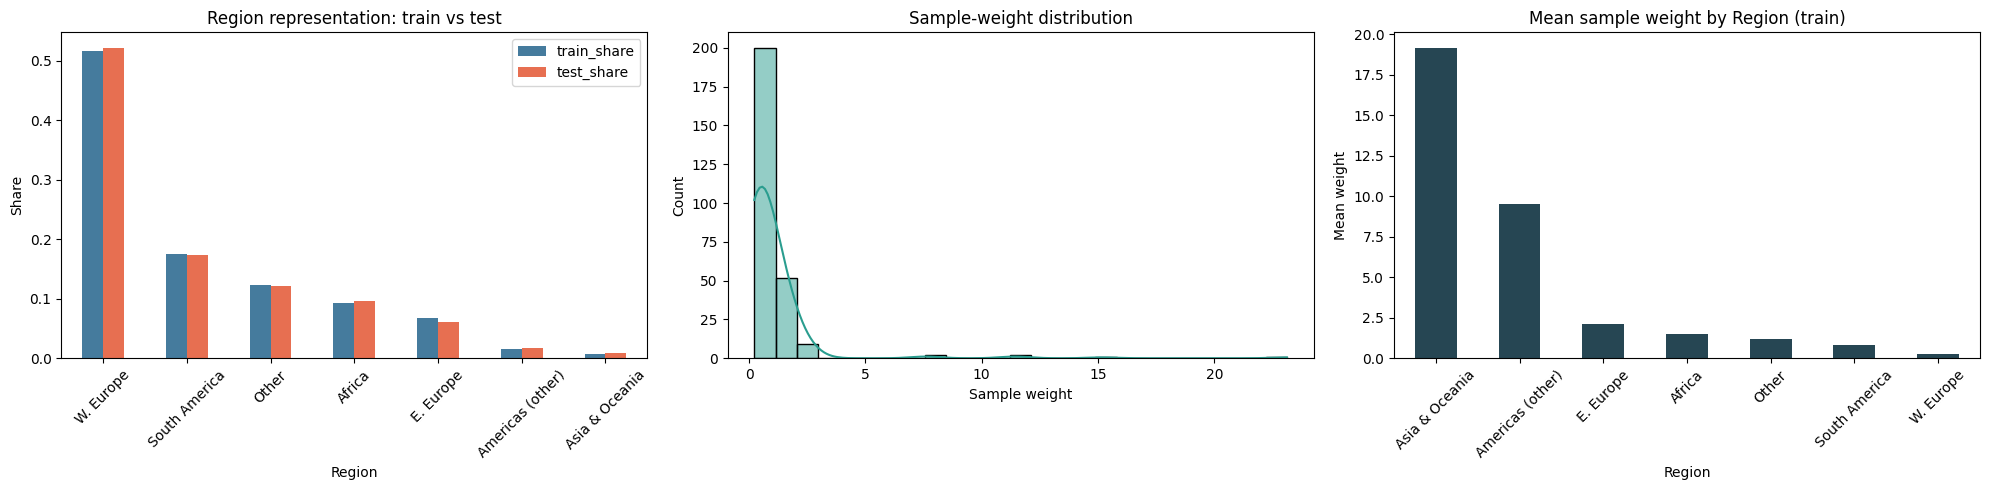

Train/Test Region share comparison:


,train_share,test_share
Region,,
W. Europe,0.517,0.522
South America,0.176,0.174
Other,0.124,0.122
Africa,0.094,0.096
E. Europe,0.067,0.061
Americas (other),0.015,0.017
Asia & Oceania,0.007,0.009


In [68]:
# --- Pre-processing visuals ---
import seaborn as sns
import matplotlib.pyplot as plt

pre_vis_df = pd.DataFrame({
    'Region': context_train['Region'].values,
    'sample_weight': sample_weight_fair
})

train_region_dist = context_train['Region'].value_counts(normalize=True).rename('train_share')
test_region_dist = context_test['Region'].value_counts(normalize=True).rename('test_share')
region_compare = pd.concat([train_region_dist, test_region_dist], axis=1).fillna(0).sort_values('train_share', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

region_compare.plot(kind='bar', ax=axes[0], color=['#457b9d', '#e76f51'])
axes[0].set_title('Region representation: train vs test')
axes[0].set_ylabel('Share')
axes[0].set_xlabel('Region')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(sample_weight_fair, bins=25, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Sample-weight distribution')
axes[1].set_xlabel('Sample weight')

region_weight_mean = pre_vis_df.groupby('Region')['sample_weight'].mean().sort_values(ascending=False)
region_weight_mean.plot(kind='bar', ax=axes[2], color='#264653')
axes[2].set_title('Mean sample weight by Region (train)')
axes[2].set_ylabel('Mean weight')
axes[2].set_xlabel('Region')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Train/Test Region share comparison:')
display(region_compare.round(3))

## 10. Model Training Experiments with In-Processing Fairness

This section trains multiple Random Forest variants and evaluates each on:
- overall performance (RMSE, R2),
- fairness disparity (signed residual gap and MAE gap across Region).

In [69]:
# --- In-processing model experiments ---
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def fairness_eval_regression(y_true, y_pred, groups):
    eval_df_local = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred,
        'group': groups
    }).copy()
    eval_df_local['residual'] = eval_df_local['y_pred'] - eval_df_local['y_true']
    eval_df_local['abs_error'] = eval_df_local['residual'].abs()

    g = eval_df_local.groupby('group').agg(
        n=('residual', 'count'),
        mean_residual=('residual', 'mean'),
        MAE=('abs_error', 'mean')
    )

    g = g[g['n'] >= 10].copy()
    if g.empty:
        signed_gap = np.nan
        mae_gap = np.nan
    else:
        signed_gap = (g['mean_residual'].max() - g['mean_residual'].min())
        mae_gap = (g['MAE'].max() - g['MAE'].min())

    return g.sort_values('MAE', ascending=False), signed_gap, mae_gap


model_specs = {
    'rf_standard': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=1, random_state=169),
    'rf_weighted': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=1, random_state=169),
    'rf_conservative': dict(n_estimators=300, max_features='sqrt', min_samples_leaf=5, random_state=169),
}

trained_models = {}
results_rows = []
fairness_tables = {}

for model_name, params in model_specs.items():
    model = RandomForestRegressor(**params)

    if model_name == 'rf_weighted':
        model.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)
    else:
        model.fit(X_train_fair, y_train_fair)

    pred_test = model.predict(X_test_fair)

    rmse = np.sqrt(mean_squared_error(y_test_fair, pred_test))
    r2 = r2_score(y_test_fair, pred_test)

    fairness_table, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_fair.values,
        y_pred=pred_test,
        groups=context_test['Region'].values
    )

    trained_models[model_name] = model
    fairness_tables[model_name] = fairness_table

    results_rows.append({
        'model': model_name,
        'RMSE': rmse,
        'R2': r2,
        'SignedResidualGap_Region': signed_gap,
        'MAEGap_Region': mae_gap
    })

results_df = pd.DataFrame(results_rows).sort_values(
    ['MAEGap_Region', 'SignedResidualGap_Region', 'RMSE'],
    ascending=[True, True, True]
)

print('Model comparison (lower gaps are fairer):')
display(results_df.round(4))

for model_name in fairness_tables:
    print(f'\nRegion-level errors for {model_name}:')
    display(fairness_tables[model_name].round(4))

Model comparison (lower gaps are fairer):


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region
1,rf_weighted,9.0544,0.7510,3.8213,3.5061
0,rf_standard,9.4991,0.7259,4.2480,4.0413
2,rf_conservative,12.4046,0.5326,4.9363,4.5423



Region-level errors for rf_standard:


,n,mean_residual,MAE
group,,,
South America,20,-1.8363,7.6671
W. Europe,60,-0.3832,5.0603
Africa,11,-0.1222,4.2226
Other,14,2.4118,3.6258



Region-level errors for rf_weighted:


,n,mean_residual,MAE
group,,,
South America,20,-1.3706,7.3539
W. Europe,60,-0.4034,5.1052
Africa,11,-0.2468,4.0536
Other,14,2.4507,3.8478



Region-level errors for rf_conservative:


,n,mean_residual,MAE
group,,,
South America,20,-2.0882,8.8470
W. Europe,60,-0.8050,6.1326
Africa,11,-0.3080,4.4410
Other,14,2.8481,4.3047


### 10.1 In-Processing Diagnostics and Visuals

Additional visuals to compare in-processing model behavior:
- performance/fairness bars,
- fairness-performance frontier,
- residual distribution by model.

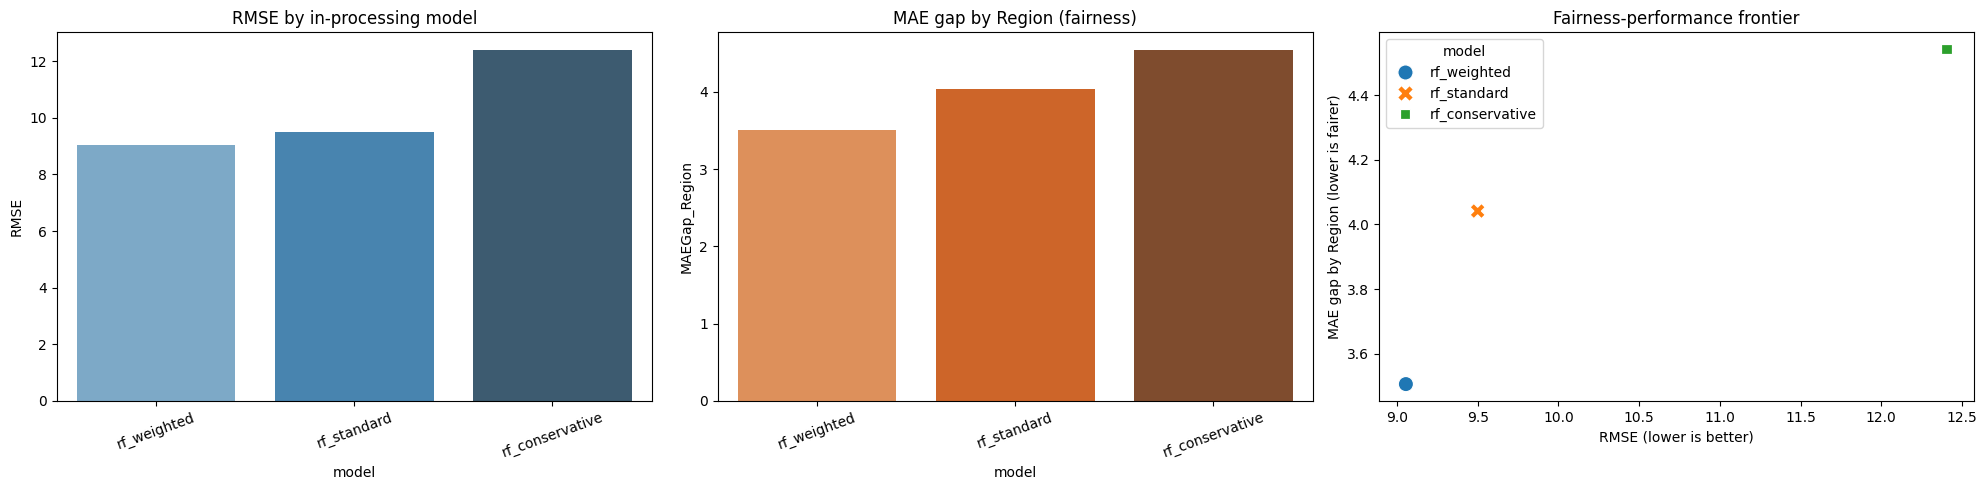

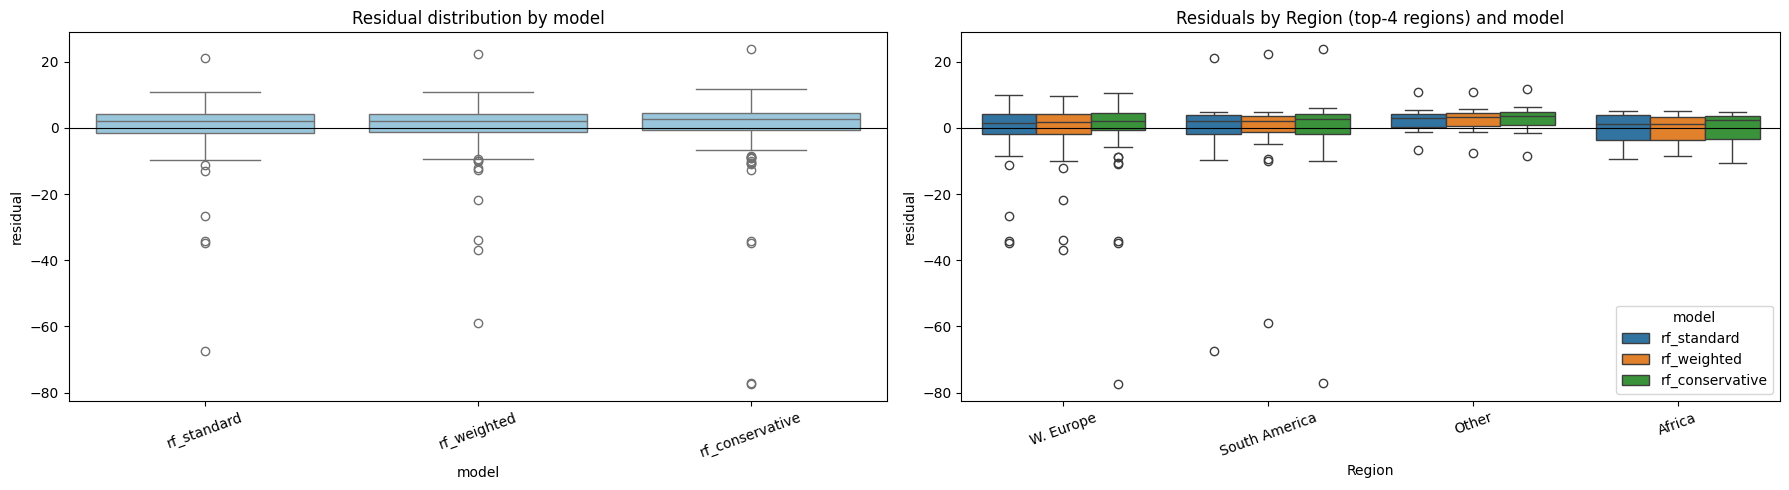

In [70]:
# --- In-processing visuals ---
import seaborn as sns
import matplotlib.pyplot as plt

vis_results = results_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=vis_results, x='model', y='RMSE', hue='model', ax=axes[0], palette='Blues_d', legend=False)
axes[0].set_title('RMSE by in-processing model')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=vis_results, x='model', y='MAEGap_Region', hue='model', ax=axes[1], palette='Oranges_d', legend=False)
axes[1].set_title('MAE gap by Region (fairness)')
axes[1].tick_params(axis='x', rotation=20)

sns.scatterplot(
    data=vis_results,
    x='RMSE', y='MAEGap_Region',
    hue='model', style='model', s=120, ax=axes[2]
)
axes[2].set_title('Fairness-performance frontier')
axes[2].set_xlabel('RMSE (lower is better)')
axes[2].set_ylabel('MAE gap by Region (lower is fairer)')

plt.tight_layout()
plt.show()

# Residual-distribution comparison by model.
residual_rows = []
for model_name, model in trained_models.items():
    pred = model.predict(X_test_fair)
    tmp = pd.DataFrame({
        'model': model_name,
        'residual': pred - y_test_fair.values,
        'Region': context_test['Region'].values
    })
    residual_rows.append(tmp)

residual_plot_df = pd.concat(residual_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(data=residual_plot_df, x='model', y='residual', ax=axes[0], color='#8ecae6')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual distribution by model')
axes[0].tick_params(axis='x', rotation=20)

region_focus = residual_plot_df[residual_plot_df['Region'].isin(residual_plot_df['Region'].value_counts().head(4).index)]
sns.boxplot(data=region_focus, x='Region', y='residual', hue='model', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals by Region (top-4 regions) and model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 11. Simpson's Paradox Check During Model Training

This section compares global group residuals against within-strata residuals (League and predicted-fee bins) to detect reversals that indicate potential Simpson's paradox.

In [71]:
# --- Simpson's paradox diagnostics ---
# Pick the fairest model from the in-processing table (first row after sorting).
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

simpson_df = context_test.copy()
simpson_df['y_true'] = y_test_fair.values
simpson_df['y_pred'] = best_model.predict(X_test_fair)
simpson_df['residual'] = simpson_df['y_pred'] - simpson_df['y_true']

# Global residual by Region.
global_region = simpson_df.groupby('Region')['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_global', 'mean': 'global_mean_residual'}
)

# Within-League residual by Region.
within_league = simpson_df.groupby(['League_from', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_league = within_league[within_league['n_within'] >= 8]

# Within predicted-fee-bin residual by Region.
simpson_df['pred_bin'] = pd.qcut(simpson_df['y_pred'], q=5, duplicates='drop').astype(str)
within_pred_bin = simpson_df.groupby(['pred_bin', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_pred_bin = within_pred_bin[within_pred_bin['n_within'] >= 8]


def paradox_flag(global_table, within_table, strata_col):
    rows = []
    for region, g_row in global_table.iterrows():
        g_mean = g_row['global_mean_residual']
        if pd.isna(g_mean) or g_row['n_global'] < 15:
            continue

        region_within = within_table[within_table['Region'] == region]
        if region_within.empty:
            continue

        same_sign_share = np.mean(np.sign(region_within['within_mean_residual']) == np.sign(g_mean))

        rows.append({
            'Region': region,
            'global_mean_residual': g_mean,
            f'strata_count_{strata_col}': region_within[strata_col].nunique(),
            f'same_sign_share_{strata_col}': same_sign_share,
            f'possible_paradox_{strata_col}': same_sign_share < 0.5
        })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values('global_mean_residual')

paradox_league = paradox_flag(global_region, within_league, 'League_from')
paradox_predbin = paradox_flag(global_region, within_pred_bin, 'pred_bin')

print(f"Simpson diagnostics based on model: {best_model_name}")
print('\nGlobal residual by Region:')
display(global_region.round(4))

print('\nPotential sign-reversal flags (within League_from strata):')
display(paradox_league.round(4))

print('\nPotential sign-reversal flags (within predicted-fee-bin strata):')
display(paradox_predbin.round(4))

Simpson diagnostics based on model: rf_weighted

Global residual by Region:


,n_global,global_mean_residual
Region,,
Africa,11,-0.2468
Americas (other),2,0.5686
Asia & Oceania,1,2.7481
E. Europe,7,1.8622
Other,14,2.4507
South America,20,-1.3706
W. Europe,60,-0.4034



Potential sign-reversal flags (within League_from strata):


,Region,global_mean_residual,strata_count_League_from,same_sign_share_League_from,possible_paradox_League_from
0,W. Europe,-0.4034,2,0.5,False



Potential sign-reversal flags (within predicted-fee-bin strata):


,Region,global_mean_residual,strata_count_pred_bin,same_sign_share_pred_bin,possible_paradox_pred_bin
0,W. Europe,-0.4034,5,0.2,True


### 11.1 Simpson's Paradox: Expanded Bucket Analysis

This expands paradox checks to more grouping buckets:
- Age bucket,
- Position bucket,
- League tier,
- Predicted-fee and true-fee bins,
- Region.

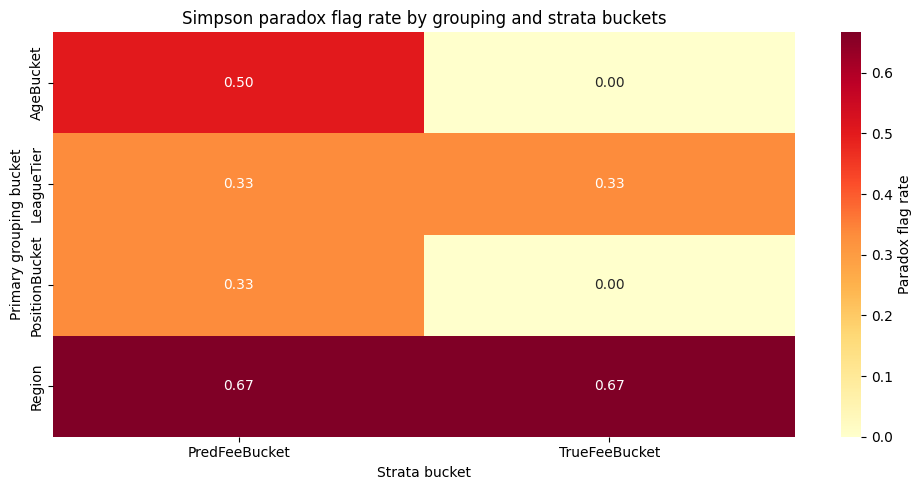

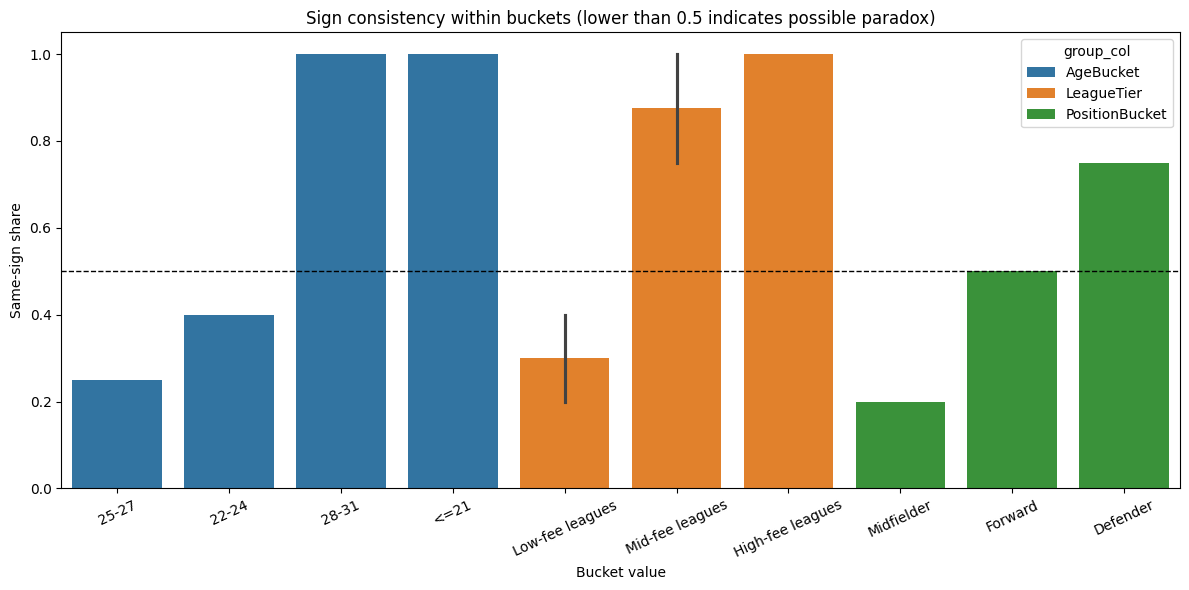

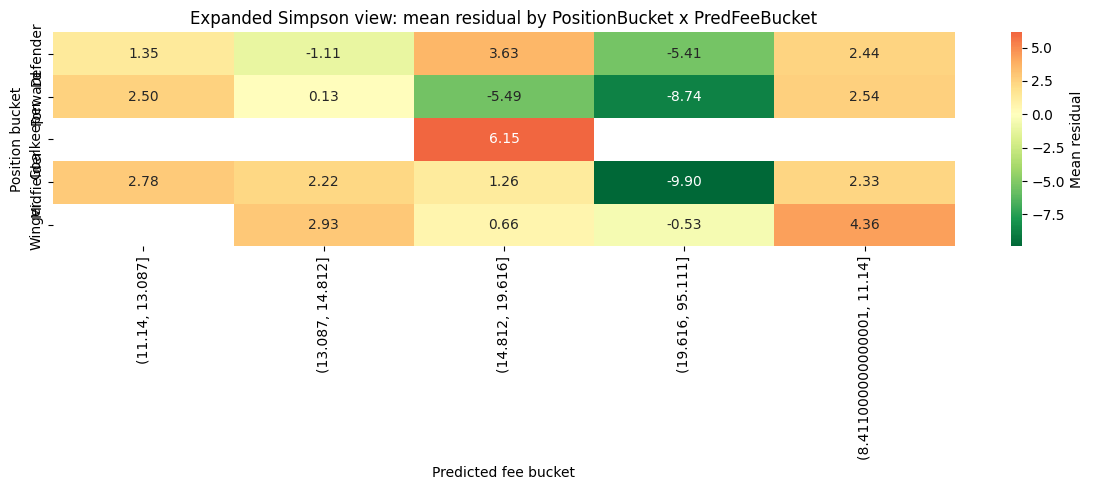

Expanded Simpson paradox table (sample):


,group_col,strata_col,group_value,n_global,global_mean_residual,same_sign_share,possible_paradox
11,PositionBucket,PredFeeBucket,Forward,24.0,-2.133,0.50,False
10,PositionBucket,PredFeeBucket,Defender,30.0,0.669,0.75,False
18,LeagueTier,TrueFeeBucket,Mid-fee leagues,44.0,1.814,0.75,False
0,Region,PredFeeBucket,Other,14.0,2.451,1.00,False
3,Region,TrueFeeBucket,Other,14.0,2.451,1.00,False
8,AgeBucket,PredFeeBucket,28-31,19.0,1.518,1.00,False
9,AgeBucket,PredFeeBucket,<=21,21.0,1.832,1.00,False
13,LeagueTier,PredFeeBucket,High-fee leagues,21.0,-2.882,1.00,False
15,LeagueTier,PredFeeBucket,Mid-fee leagues,44.0,1.814,1.00,False
16,LeagueTier,TrueFeeBucket,High-fee leagues,21.0,-2.882,1.00,False


In [72]:
# --- Expanded Simpson's paradox bucket analysis ---
import seaborn as sns
import matplotlib.pyplot as plt

# Build richer analysis frame using available columns.
if 'base_df' in globals():
    aux_df = base_df.loc[X_test_fair.index].copy()
else:
    aux_df = transfers_cleaned.loc[X_test_fair.index].copy()

simpson_ext = pd.DataFrame(index=X_test_fair.index)
simpson_ext['Region'] = context_test['Region'].values
simpson_ext['League_from'] = context_test['League_from'].values
simpson_ext['y_true'] = y_test_fair.values
simpson_ext['y_pred'] = best_model.predict(X_test_fair)
simpson_ext['residual'] = simpson_ext['y_pred'] - simpson_ext['y_true']

if 'Age' in aux_df.columns:
    simpson_ext['AgeBucket'] = pd.cut(
        aux_df['Age'].astype(float),
        bins=[0, 21, 24, 27, 31, 60],
        labels=['<=21', '22-24', '25-27', '28-31', '32+'],
        include_lowest=True
    ).astype(str)
else:
    simpson_ext['AgeBucket'] = 'Unknown'

if 'Position' in aux_df.columns:
    pos_map_local = {
        'Centre-Back': 'Defender', 'Left-Back': 'Defender', 'Right-Back': 'Defender', 'Defender': 'Defender',
        'Defensive Midfield': 'Midfielder', 'Central Midfield': 'Midfielder', 'Attacking Midfield': 'Midfielder',
        'Midfielder': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Midfield': 'Midfielder',
        'Left Winger': 'Winger', 'Right Winger': 'Winger',
        'Second Striker': 'Forward', 'Forward': 'Forward', 'Centre-Forward': 'Forward',
        'Goalkeeper': 'Goalkeeper'
    }
    simpson_ext['PositionBucket'] = aux_df['Position'].map(pos_map_local).fillna('Other')
else:
    simpson_ext['PositionBucket'] = 'Unknown'

simpson_ext['PredFeeBucket'] = pd.qcut(simpson_ext['y_pred'], q=5, duplicates='drop').astype(str)
simpson_ext['TrueFeeBucket'] = pd.qcut(simpson_ext['y_true'], q=5, duplicates='drop').astype(str)

# League tier derived from overall median transfer fee in source data.
league_fee_median = transfers_cleaned.groupby('League_from')['Transfer_fee_in_mln'].median()
simpson_ext['LeagueMedianFee'] = simpson_ext['League_from'].map(league_fee_median)
simpson_ext['LeagueTier'] = pd.qcut(simpson_ext['LeagueMedianFee'], q=3, duplicates='drop', labels=['Low-fee leagues', 'Mid-fee leagues', 'High-fee leagues']).astype(str)


def paradox_grid(df, group_col, strata_col, min_global=12, min_within=6):
    global_tab = df.groupby(group_col)['residual'].agg(['count', 'mean']).rename(columns={'count': 'n_global', 'mean': 'global_mean'})
    within_tab = df.groupby([strata_col, group_col])['residual'].agg(['count', 'mean']).rename(columns={'count': 'n_within', 'mean': 'within_mean'}).reset_index()
    within_tab = within_tab[within_tab['n_within'] >= min_within]

    rows = []
    for g, row in global_tab.iterrows():
        if row['n_global'] < min_global:
            continue
        g_slice = within_tab[within_tab[group_col] == g]
        if g_slice.empty:
            continue

        same_sign_share = (np.sign(g_slice['within_mean']) == np.sign(row['global_mean'])).mean()
        rows.append({
            'group_col': group_col,
            'strata_col': strata_col,
            'group_value': g,
            'n_global': row['n_global'],
            'global_mean_residual': row['global_mean'],
            'same_sign_share': same_sign_share,
            'possible_paradox': same_sign_share < 0.5
        })

    return pd.DataFrame(rows)

analysis_pairs = [
    ('Region', 'PredFeeBucket'),
    ('Region', 'TrueFeeBucket'),
    ('AgeBucket', 'PredFeeBucket'),
    ('PositionBucket', 'PredFeeBucket'),
    ('LeagueTier', 'PredFeeBucket'),
    ('LeagueTier', 'TrueFeeBucket'),
]

paradox_frames = []
for gcol, scol in analysis_pairs:
    out = paradox_grid(simpson_ext, gcol, scol)
    if not out.empty:
        paradox_frames.append(out)

if len(paradox_frames) == 0:
    raise ValueError('No expanded paradox outputs were produced. Consider lowering min thresholds.')

paradox_expanded = pd.concat(paradox_frames, ignore_index=True)

summary_heat = paradox_expanded.groupby(['group_col', 'strata_col'])['possible_paradox'].mean().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(summary_heat, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Paradox flag rate'})
plt.title('Simpson paradox flag rate by grouping and strata buckets')
plt.xlabel('Strata bucket')
plt.ylabel('Primary grouping bucket')
plt.tight_layout()
plt.show()

# Visualize sign consistency for key expanded groups.
focus = paradox_expanded[paradox_expanded['group_col'].isin(['AgeBucket', 'PositionBucket', 'LeagueTier'])].copy()
focus = focus.sort_values(['group_col', 'same_sign_share'])

plt.figure(figsize=(12, 6))
sns.barplot(data=focus, x='group_value', y='same_sign_share', hue='group_col')
plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
plt.title('Sign consistency within buckets (lower than 0.5 indicates possible paradox)')
plt.xlabel('Bucket value')
plt.ylabel('Same-sign share')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Residual heatmap for one expanded view: PositionBucket x PredFeeBucket.
pos_pred_pivot = simpson_ext.groupby(['PositionBucket', 'PredFeeBucket'])['residual'].mean().unstack()
plt.figure(figsize=(12, 5))
sns.heatmap(pos_pred_pivot, annot=True, fmt='.2f', center=0, cmap='RdYlGn_r', cbar_kws={'label': 'Mean residual'})
plt.title('Expanded Simpson view: mean residual by PositionBucket x PredFeeBucket')
plt.xlabel('Predicted fee bucket')
plt.ylabel('Position bucket')
plt.tight_layout()
plt.show()

print('Expanded Simpson paradox table (sample):')
display(paradox_expanded.sort_values(['possible_paradox', 'same_sign_share']).head(20).round(3))

## 12. Hierarchical Strategy: Global Model + Group Residual Models

This section trains a hierarchical approach:
- a global random forest for base signal,
- per-region residual models for groups with enough training data,
- fallback to global-only predictions for sparse groups.

In [73]:
# --- Hierarchical model training ---
min_group_n = 80

# Global model uses fairness-aware sample weights from Section 9.
global_model = RandomForestRegressor(
    n_estimators=350,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=169
)
global_model.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)

# Train-group residual targets.
global_pred_train = global_model.predict(X_train_fair)
residual_train = y_train_fair.values - global_pred_train

train_h = X_train_fair.copy()
train_h['Region'] = context_train['Region'].values
train_h['residual_target'] = residual_train

# Fit one residual model per sufficiently large Region.
region_models = {}
region_counts = train_h['Region'].value_counts()
eligible_regions = region_counts[region_counts >= min_group_n].index.tolist()

for region in eligible_regions:
    subset = train_h[train_h['Region'] == region]
    X_r = subset.drop(columns=['Region', 'residual_target'])
    y_r = subset['residual_target'].values

    # Small residual model to avoid overfitting sparse local structure.
    region_model = RandomForestRegressor(
        n_estimators=120,
        max_features='sqrt',
        min_samples_leaf=8,
        random_state=169
    )
    region_model.fit(X_r, y_r)
    region_models[region] = region_model

# Predict on test set: global + optional region residual correction.
global_pred_test = global_model.predict(X_test_fair)
hier_pred_test = global_pred_test.copy()

for i, idx in enumerate(X_test_fair.index):
    region = context_test.loc[idx, 'Region']
    if region in region_models:
        row_features = X_test_fair.loc[[idx]]
        correction = region_models[region].predict(row_features)[0]
        hier_pred_test[i] += correction

# Compare hierarchical against best in-processing single model.
best_single_name = results_df.iloc[0]['model']
best_single_model = trained_models[best_single_name]
best_single_pred = best_single_model.predict(X_test_fair)

comparison_rows = []
for label, preds in [
    (f'single_{best_single_name}', best_single_pred),
    ('hierarchical_global_plus_region', hier_pred_test)
]:
    rmse = np.sqrt(mean_squared_error(y_test_fair, preds))
    r2 = r2_score(y_test_fair, preds)
    fair_tbl, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_fair.values,
        y_pred=preds,
        groups=context_test['Region'].values
    )

    comparison_rows.append({
        'model': label,
        'RMSE': rmse,
        'R2': r2,
        'SignedResidualGap_Region': signed_gap,
        'MAEGap_Region': mae_gap,
        'RegionsWithResidualModel': len(region_models)
    })

hier_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['MAEGap_Region', 'SignedResidualGap_Region', 'RMSE'],
    ascending=[True, True, True]
)

print('Hierarchical strategy comparison:')
display(hier_comparison_df.round(4))

print('Regions with local residual models:')
print(sorted(region_models.keys()))

Hierarchical strategy comparison:


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region,RegionsWithResidualModel
0,single_rf_weighted,9.0544,0.7510,3.8213,3.5061,1
1,hierarchical_global_plus_region,9.4909,0.7264,4.1254,3.8487,1


Regions with local residual models:
['W. Europe']


## 13. Explainability: SHAP, LIME, ICE, and PDP

This section adds local and global explainability for the selected training model:
- SHAP global and dependence views,
- LIME local explanation for a hard-to-predict transfer,
- PDP and ICE plots for key model features.

In [79]:
# --- Explainability setup (model, data, and dependencies) ---
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import PartialDependenceDisplay


def _ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {pkg_name}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])
        return importlib.import_module(import_name)


shap = _ensure_package('shap')
_ensure_package('lime')
from lime.lime_tabular import LimeTabularExplainer

# Prefer the best in-processing model when available.
if 'trained_models' in globals() and 'results_df' in globals() and len(results_df) > 0:
    explanation_model_name = results_df.iloc[0]['model']
    explanation_model = trained_models[explanation_model_name]
    X_train_exp = X_train_fair.copy()
    X_test_exp = X_test_fair.copy()
    y_test_exp = y_test_fair.copy()
elif 'rfr' in globals() and 'X_train' in globals() and 'X_test' in globals() and 'y_test' in globals():
    explanation_model_name = 'rfr'
    explanation_model = rfr
    X_train_exp = X_train.copy()
    X_test_exp = X_test.copy()
    y_test_exp = y_test.copy()
else:
    explanation_model_name = 'rfr_baseline'
    explanation_model = rfr_baseline
    X_train_exp = X_train_base.copy()
    X_test_exp = X_test_base.copy()
    y_test_exp = y_test_base.copy()

feature_importance = pd.Series(
    explanation_model.feature_importances_,
    index=X_train_exp.columns
).sort_values(ascending=False)

# Favor features with richer value ranges for ICE/PDP readability.
continuous_like = [c for c in X_train_exp.columns if X_train_exp[c].nunique() > 10]
pdp_candidate_features = [c for c in feature_importance.index if c in continuous_like][:4]
if len(pdp_candidate_features) < 4:
    extras = [c for c in continuous_like if c not in pdp_candidate_features]
    pdp_candidate_features = (pdp_candidate_features + extras)[:4]

print(f'Explainability model: {explanation_model_name}')
print('Train shape:', X_train_exp.shape, '| Test shape:', X_test_exp.shape)
print('\nTop features by importance:')
display(feature_importance.head(12).round(5))
print('PDP/ICE features:', pdp_candidate_features)

Explainability model: rf_weighted
Train shape: (267, 37) | Test shape: (115, 37)

Top features by importance:


Market_value_in_mln           0.27408
potential                     0.22391
overall                       0.14684
league_median_fee_to          0.04708
Age                           0.03343
season_mean_fee               0.02877
Season_transferred            0.02455
League_from_Other             0.01673
League_to_Premier League      0.01505
League_from_LaLiga            0.01317
League_from_Premier League    0.01246
age_bucket_20-23              0.01227
dtype: float64

PDP/ICE features: ['Market_value_in_mln', 'potential', 'overall', 'league_median_fee_to']


## 13.2 Scenario-Based LIME Case Studies

This section replaces the generic multi-instance LIME pass with five scenario-based case studies so the local explanations are tied to concrete football transfer archetypes.

Computing SHAP values...


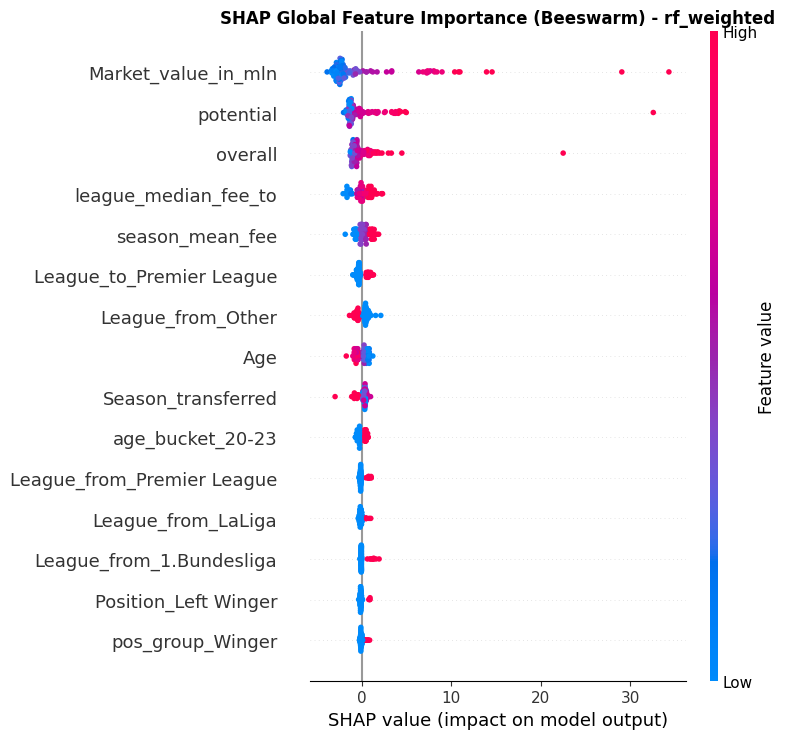

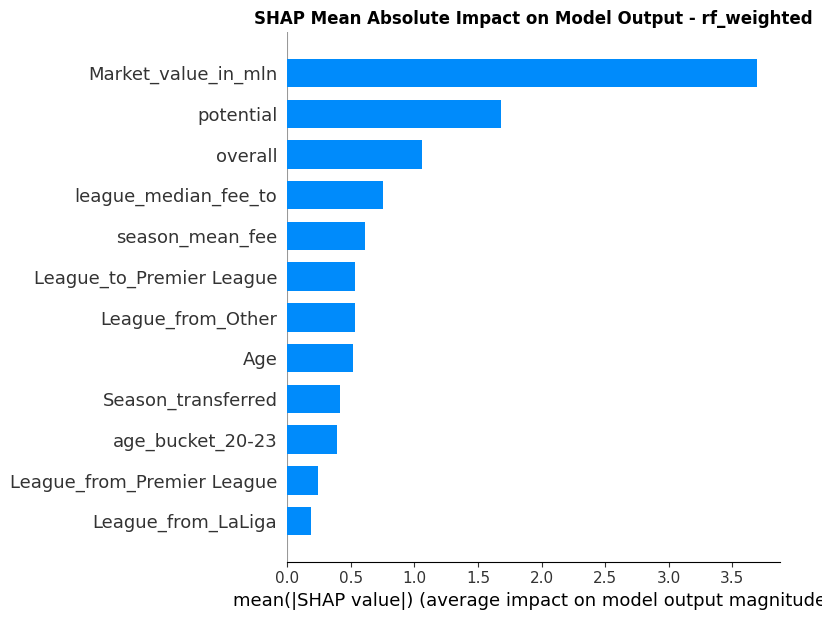

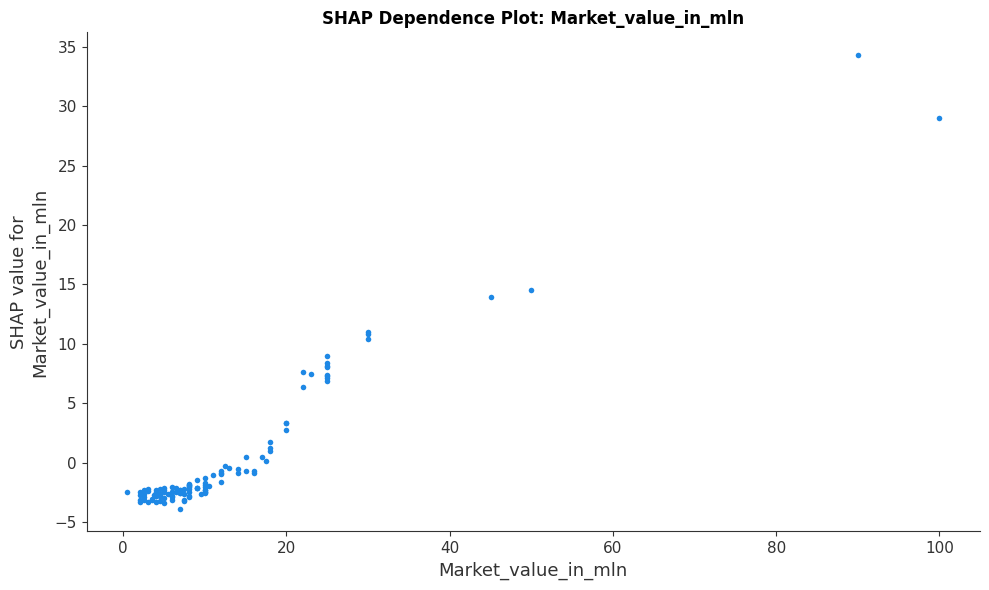


[SHAP] Analyzed 115 instances

SHAP Analysis Disaggregated by Group


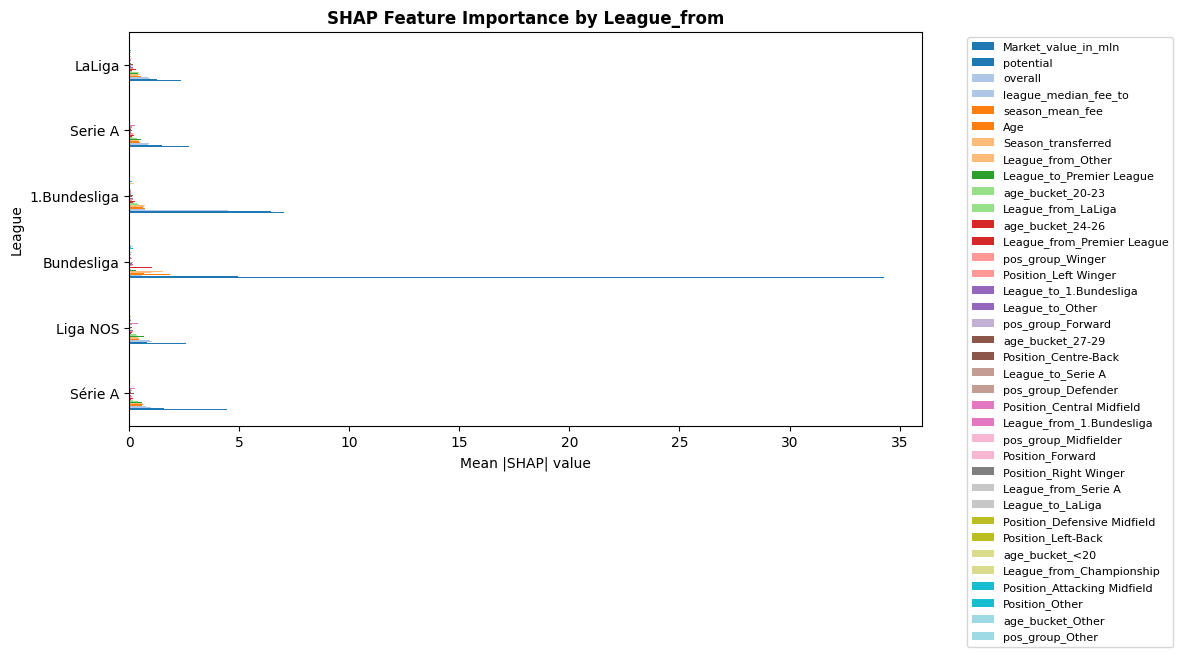


Top feature importance by League:
  Série A             : Market_value_in_mln (mean |SHAP|=4.4311)
  Liga NOS            : Market_value_in_mln (mean |SHAP|=2.5740)
  Bundesliga          : Market_value_in_mln (mean |SHAP|=34.3143)
  1.Bundesliga        : Market_value_in_mln (mean |SHAP|=7.0178)
  Serie A             : Market_value_in_mln (mean |SHAP|=2.6943)
  LaLiga              : Market_value_in_mln (mean |SHAP|=2.3563)


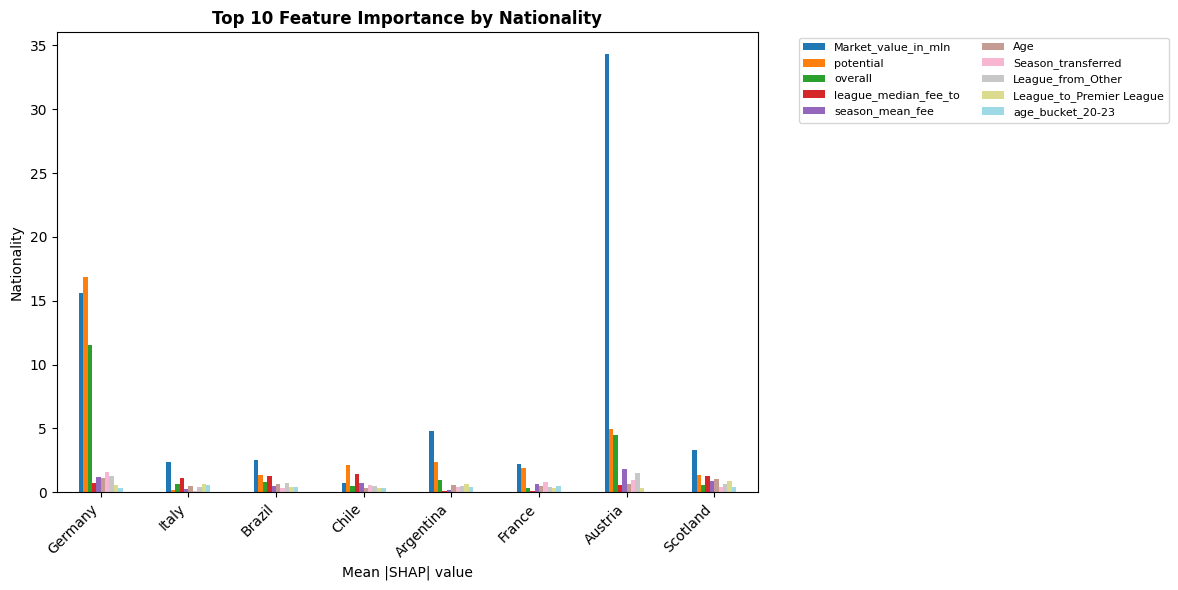


✓ SHAP analysis complete


In [75]:
# --- SHAP Global & Group-Level Analysis ---
import seaborn as sns
import matplotlib.pyplot as plt

# Create SHAP sample
sample_n = min(300, len(X_test_exp))
X_shap = X_test_exp.sample(sample_n, random_state=42)
shap_idx = X_shap.index

# Get group information for SHAP instances (safely)
shap_groups = pd.DataFrame(index=shap_idx)
if 'eval_df' in globals():
    # Only keep indices that exist in eval_df
    valid_idx = shap_idx.intersection(eval_df.index)
    if len(valid_idx) > 0:
        for col in ['League_from', 'Nationality', 'Region']:
            if col in eval_df.columns:
                shap_groups.loc[valid_idx, col] = eval_df.loc[valid_idx, col]

# Compute SHAP values
print("Computing SHAP values...")
shap_explainer = shap.TreeExplainer(explanation_model)
shap_values = shap_explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# --- SHAP Plot 1: Global Summary (Beeswarm) ---
fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title(f'SHAP Global Feature Importance (Beeswarm) - {explanation_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- SHAP Plot 2: Global Bar Chart ---
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=12, show=False)
plt.title(f'SHAP Mean Absolute Impact on Model Output - {explanation_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# --- SHAP Plot 3: Dependence Plot for Top Feature ---
dep_feature = feature_importance.index[0]
fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(dep_feature, shap_values, X_shap, interaction_index=None, show=False, ax=ax)
ax.set_title(f'SHAP Dependence Plot: {dep_feature}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n[SHAP] Analyzed {len(shap_values)} instances")

# --- SHAP Analysis Disaggregated by League/Nationality ---
print("\n" + "="*80)
print("SHAP Analysis Disaggregated by Group")
print("="*80)

if 'League_from' in shap_groups.columns and shap_groups['League_from'].notna().sum() > 0:
    # Aggregate SHAP absolute values by league
    shap_abs = np.abs(shap_values)
    shap_by_league = pd.DataFrame(index=X_shap.columns)
    
    for league in shap_groups['League_from'].dropna().unique():
        league_mask = (shap_groups['League_from'] == league).values
        if league_mask.sum() > 0:
            shap_by_league[league] = shap_abs[league_mask].mean(axis=0)
    
    shap_by_league = shap_by_league[shap_by_league.columns[:6]]  # Top 6 leagues
    
    fig, ax = plt.subplots(figsize=(12, 6))
    shap_by_league.T.plot(kind='barh', ax=ax, colormap='tab20')
    ax.set_xlabel('Mean |SHAP| value')
    ax.set_ylabel('League')
    ax.set_title('SHAP Feature Importance by League_from', fontsize=12, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()
    
    print("\nTop feature importance by League:")
    for league in shap_by_league.columns:
        top_feat = shap_by_league[league].idxmax()
        print(f"  {league:20s}: {top_feat} (mean |SHAP|={shap_by_league.loc[top_feat, league]:.4f})")

if 'Nationality' in shap_groups.columns and shap_groups['Nationality'].notna().sum() > 0:
    # Aggregate SHAP by top nationalities
    top_nat = shap_groups['Nationality'].value_counts().head(8).index
    shap_by_nat = pd.DataFrame(index=X_shap.columns)
    
    for nat in top_nat:
        nat_mask = (shap_groups['Nationality'] == nat).values
        if nat_mask.sum() > 0:
            shap_by_nat[nat] = shap_abs[nat_mask].mean(axis=0)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    shap_by_nat.head(10).T.plot(kind='bar', ax=ax, colormap='tab20')
    ax.set_xlabel('Mean |SHAP| value')
    ax.set_ylabel('Nationality')
    ax.set_title('Top 10 Feature Importance by Nationality', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

print("\n✓ SHAP analysis complete")

Scenario-based LIME cases:


,Scenario,Player,Age,Actual fee (M),Pred fee (M),Abs error (M),Top positive drivers,Top negative drivers
0,Young Brazilian league player,Rodrigo Bentancur,20,10.50,11.831,1.331,"season_mean_fee > 18.05, Age <= 23.00, pos_gro...","Market_value_in_mln <= 6.00, overall <= 73.00,..."
1,English player to English team,Theo Walcott,28,22.50,22.349,0.151,"Market_value_in_mln > 15.00, overall > 79.50, ...","78.00 < potential <= 81.00, League_from_1.Bund..."
2,Superstar to juggernaut,Antoine Griezmann,25,125.00,66.011,58.989,"Market_value_in_mln > 15.00, potential > 84.00...","League_to_Premier League <= 0.00, League_from_..."
3,Older player to retirement league,Ezequiel Barco,18,12.28,11.360,0.920,,"6.00 < Market_value_in_mln <= 9.00, potential ..."
4,Mid-tier player to mid-tier league,Marcos Acuña,25,9.59,10.703,1.113,season_mean_fee > 18.05,"6.00 < Market_value_in_mln <= 9.00, 78.00 < po..."


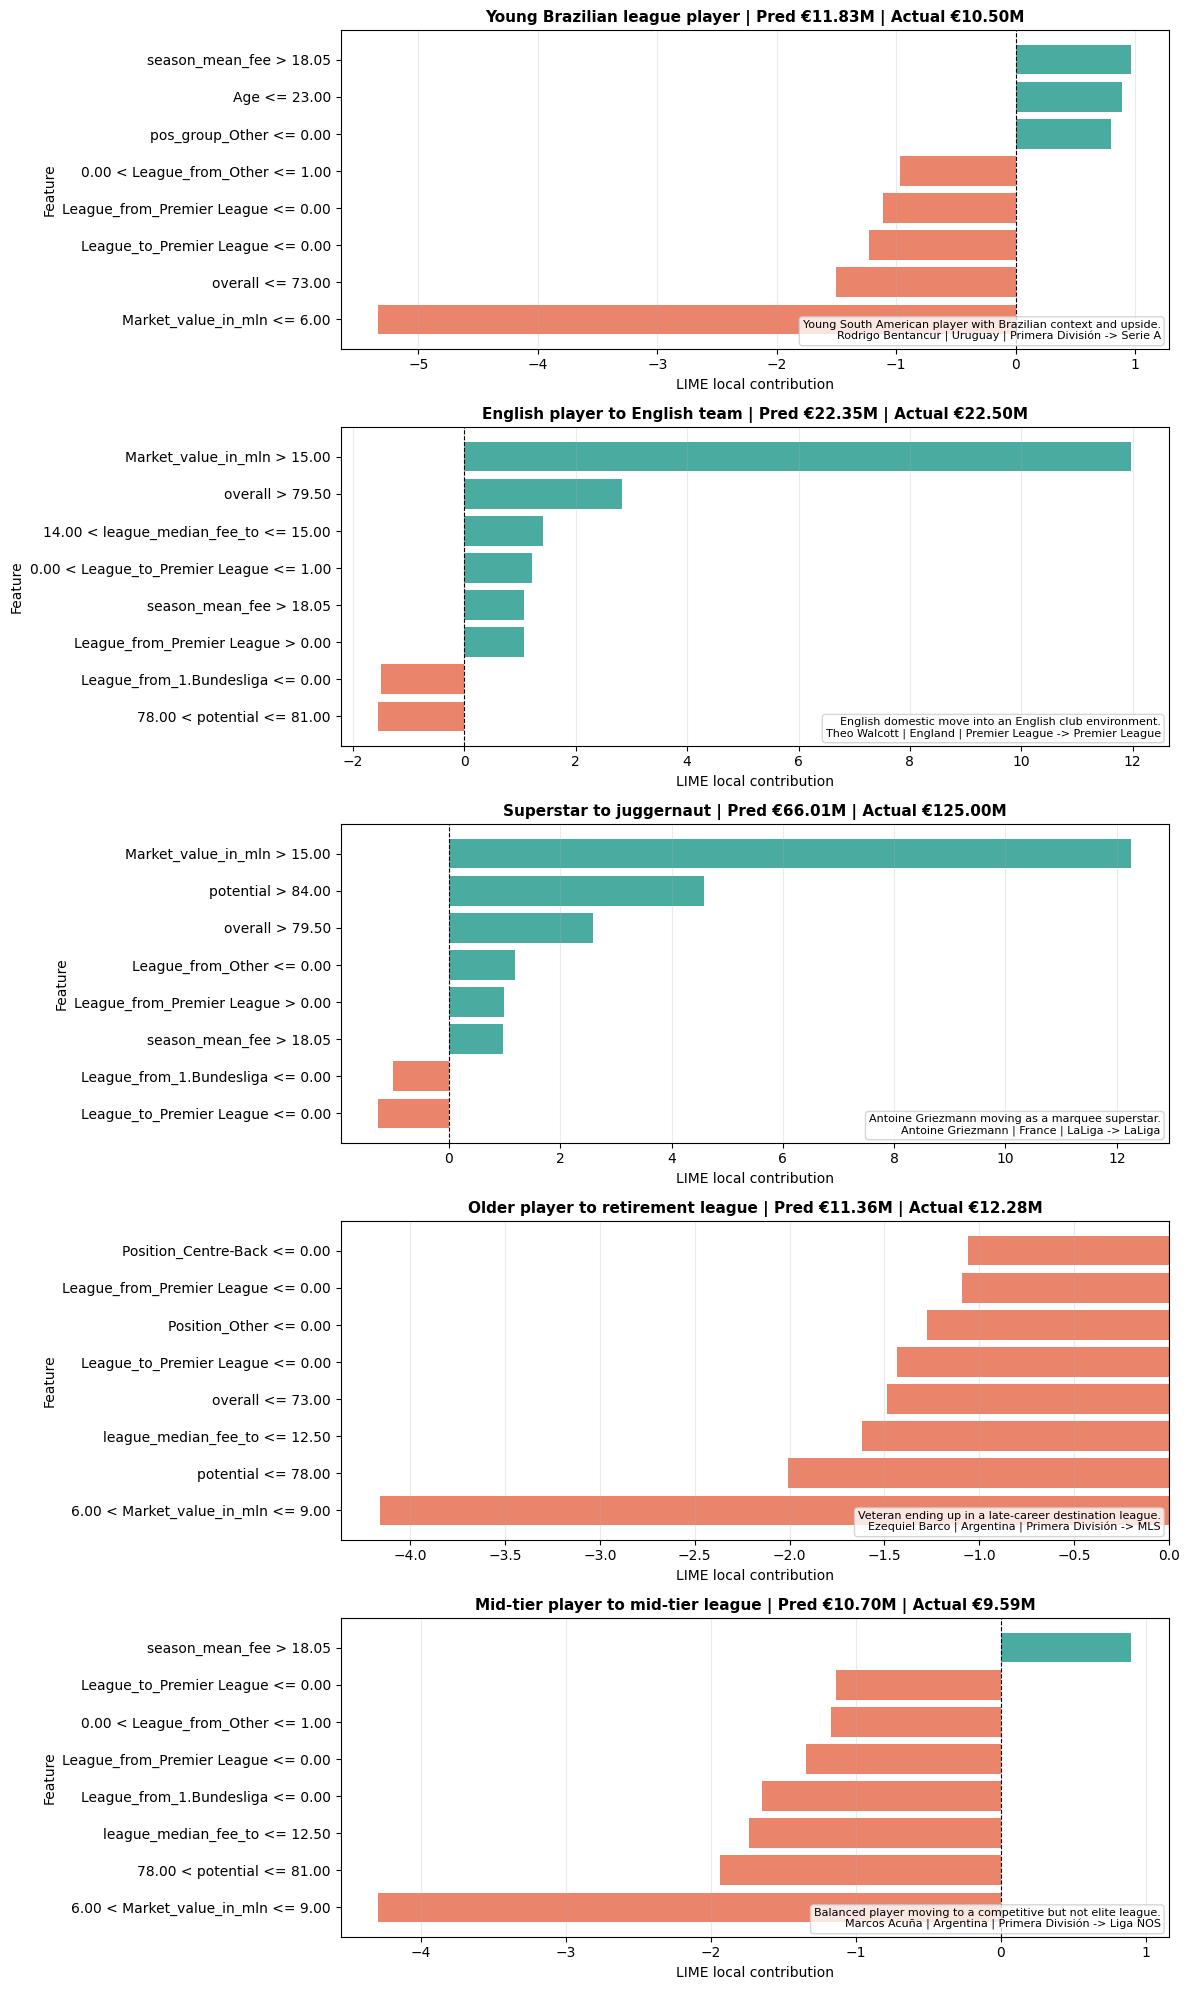

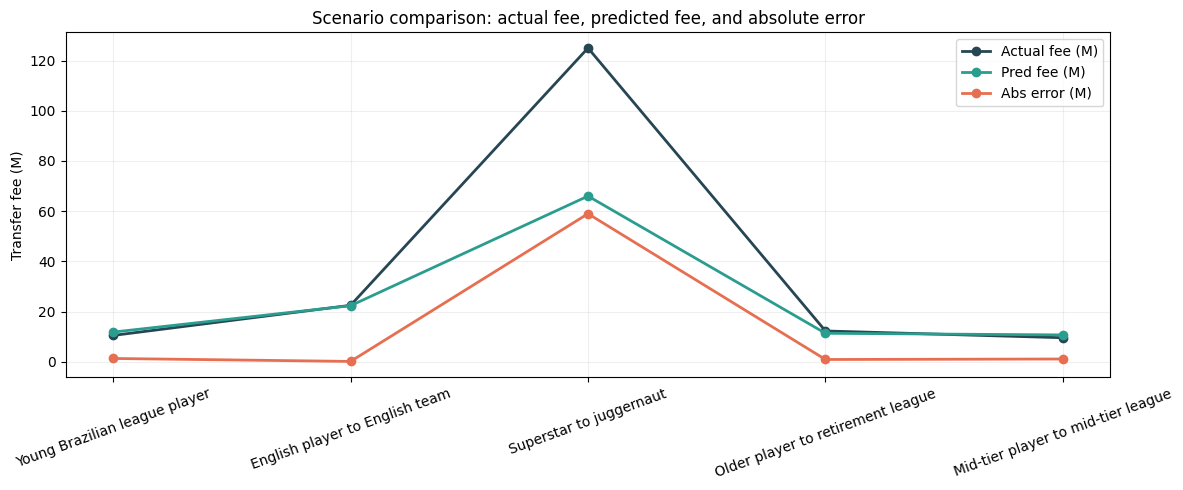

LIME scenario analysis complete.


In [ ]:
# --- Scenario-based LIME case studies ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'LimeTabularExplainer' not in globals():
    raise ValueError('Run the explainability setup cell before this section.')

def predict_for_lime(arr):
    arr_df = pd.DataFrame(arr, columns=X_train_exp.columns)
    return explanation_model.predict(arr_df)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_exp.values,
    feature_names=X_train_exp.columns.tolist(),
    mode='regression',
    discretize_continuous=True,
    random_state=42
)

def _first_existing(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None

def _filter_text(frame, column, terms):
    if column is None or column not in frame.columns or not terms:
        return frame
    values = frame[column].astype(str).fillna('')
    mask = pd.Series(False, index=frame.index)
    for term in terms:
        mask |= values.str.contains(term, case=False, na=False)
    filtered = frame[mask]
    return filtered if len(filtered) > 0 else frame

def _pick_case(frame, spec):
    candidates = frame.copy()
    if spec.get('player_terms'):
        search_frame = candidates if len(candidates) > 0 else (base_df.copy() if 'base_df' in globals() else frame.copy())
        player_mask = pd.Series(False, index=search_frame.index)
        for term in spec['player_terms']:
            if 'Name' in search_frame.columns:
                player_mask |= search_frame['Name'].astype(str).str.contains(term, case=False, na=False)
            if 'Lastname' in search_frame.columns:
                player_mask |= search_frame['Lastname'].astype(str).str.contains(term, case=False, na=False)
        matched_players = search_frame[player_mask]
        if len(matched_players) > 0:
            candidates = matched_players
    if spec.get('region_values') and 'Region' in candidates.columns:
        region_mask = candidates['Region'].isin(spec['region_values'])
        if region_mask.any():
            candidates = candidates[region_mask]
    if spec.get('age_min') is not None and 'Age' in candidates.columns:
        age_mask = pd.to_numeric(candidates['Age'], errors='coerce') >= spec['age_min']
        if age_mask.any():
            candidates = candidates[age_mask]
    if spec.get('age_max') is not None and 'Age' in candidates.columns:
        age_mask = pd.to_numeric(candidates['Age'], errors='coerce') <= spec['age_max']
        if age_mask.any():
            candidates = candidates[age_mask]
    for column, terms in [
        ('Nationality', spec.get('nationality_terms')),
        ('League_from', spec.get('league_from_terms')),
        ('League_to', spec.get('league_to_terms')),
        ('Team_from', spec.get('team_from_terms')),
        ('Team_to', spec.get('team_to_terms')),
        ('Position', spec.get('position_terms')),
    ]:
        candidates = _filter_text(candidates, column, terms)

    if len(candidates) == 0:
        candidates = frame.copy()

    score = pd.Series(0.0, index=candidates.index)
    age_col = 'Age' if 'Age' in candidates.columns else None
    market_col = _first_existing(candidates.columns, ['Market_value_in_mln', 'Market_value'])
    overall_col = _first_existing(candidates.columns, ['overall', 'Overall'])
    potential_col = _first_existing(candidates.columns, ['potential', 'Potential'])

    if spec.get('age_target') is not None and age_col is not None:
        score += (pd.to_numeric(candidates[age_col], errors='coerce') - spec['age_target']).abs().fillna(999) / 3.0
    if spec.get('market_target') is not None and market_col is not None:
        scale = max(1.0, float(spec['market_target']))
        score += (pd.to_numeric(candidates[market_col], errors='coerce') - spec['market_target']).abs().fillna(999) / scale
    if spec.get('overall_target') is not None and overall_col is not None:
        score += (pd.to_numeric(candidates[overall_col], errors='coerce') - spec['overall_target']).abs().fillna(999) / 8.0
    if spec.get('potential_target') is not None and potential_col is not None:
        score += (pd.to_numeric(candidates[potential_col], errors='coerce') - spec['potential_target']).abs().fillna(999) / 8.0

    if market_col is not None and spec.get('prefer_high_market'):
        market_rank = pd.to_numeric(candidates[market_col], errors='coerce').rank(pct=True)
        score -= market_rank.fillna(0) * 0.25

    if score.dropna().empty:
        return candidates.index[0]

    return score.sort_values().index[0]

# Build a held-out pool so the cases are explainable and still unseen by the model.
scenario_pool = base_df.loc[X_test_exp.index].copy() if 'base_df' in globals() else transfers_cleaned.loc[X_test_exp.index].copy()
if 'context_test' in globals() and 'Region' in context_test.columns:
    scenario_pool['Region'] = context_test['Region'].reindex(scenario_pool.index).values
if 'y_test_exp' in globals():
    scenario_pool['actual_fee_mln'] = y_test_exp.reindex(scenario_pool.index).values
else:
    scenario_pool['actual_fee_mln'] = np.nan
scenario_pool['predicted_fee_mln'] = explanation_model.predict(X_test_exp)
scenario_pool['abs_error_mln'] = (scenario_pool['predicted_fee_mln'] - scenario_pool['actual_fee_mln']).abs()

market_col = _first_existing(scenario_pool.columns, ['Market_value_in_mln', 'Market_value'])
overall_col = _first_existing(scenario_pool.columns, ['overall', 'Overall'])
potential_col = _first_existing(scenario_pool.columns, ['potential', 'Potential'])

median_market = float(pd.to_numeric(scenario_pool[market_col], errors='coerce').median()) if market_col is not None else None
median_overall = float(pd.to_numeric(scenario_pool[overall_col], errors='coerce').median()) if overall_col is not None else None
median_potential = float(pd.to_numeric(scenario_pool[potential_col], errors='coerce').median()) if potential_col is not None else None

scenario_specs = [
    {
        'label': 'Young Brazilian league player',
        'description': 'Young South American player with Brazilian context and upside.',
        'region_values': ['South America'],
        'age_min': 16,
        'age_max': 21,
        'nationality_terms': ['Brazil'],
        'league_from_terms': ['Brazil'],
        'league_to_terms': ['England', 'Spain', 'Portugal', 'Italy', 'France', 'Netherlands', 'Germany'],
        'age_target': 19,
        'market_target': 20.0,
        'overall_target': 74,
        'potential_target': 84,
    },
    {
        'label': 'English player to English team',
        'description': 'English domestic move into an English club environment.',
        'nationality_terms': ['England'],
        'league_to_terms': ['Premier League'],
        'team_to_terms': ['Liverpool', 'Manchester City', 'Man City', 'Manchester United', 'Man Utd', 'Arsenal', 'Chelsea', 'Tottenham', 'Aston Villa', 'Everton', 'West Ham'],
        'age_target': 26,
        'market_target': 20.0,
        'overall_target': 80,
        'potential_target': 82,
    },
    {
        'label': 'Superstar to juggernaut',
        'description': 'Antoine Griezmann moving as a marquee superstar.',
        'player_terms': ['Griezmann'],
        'display_player': 'Antoine Griezmann',
        'display_nationality': 'France',
        'display_league_from': 'LaLiga',
        'display_league_to': 'LaLiga',
        'display_team_from': 'Barcelona',
        'display_team_to': 'Atletico Madrid',
        'league_to_terms': ['Premier League', 'LaLiga', '1.Bundesliga', 'Serie A'],
        'team_to_terms': ['Barcelona', 'Atletico Madrid', 'Atlético Madrid', 'Real Madrid', 'Bayern', 'Bayern Munich', 'PSG', 'Paris Saint-Germain', 'Manchester United', 'Chelsea'],
        'age_min': 20,
        'age_max': 32,
        'age_target': 27,
        'market_target': 100,
        'overall_target': 88,
        'potential_target': 90,
        'prefer_high_market': True,
    },
    {
        'label': 'Older player to retirement league',
        'description': 'Veteran moving from a top-5 league to Saudi, MLS, or a similar retirement destination.',
        'age_min': 34,
        'age_max': 40,
        'league_from_terms': ['Premier League', 'LaLiga', '1.Bundesliga', 'Serie A', 'Ligue 1'],
        'league_to_terms': ['Saudi', 'Qatar', 'China', 'MLS', 'United States', 'Japan', 'Korea', 'UAE'],
        'team_from_terms': ['Manchester United', 'Manchester City', 'Liverpool', 'Chelsea', 'Arsenal', 'Tottenham', 'Real Madrid', 'Barcelona', 'Atletico Madrid', 'Bayern', 'Bayern Munich', 'PSG', 'Paris Saint-Germain', 'Juventus', 'Inter', 'Milan', 'Napoli', 'Lyon', 'Marseille', 'Monaco'],
        'team_to_terms': ['Saudi', 'Qatar', 'China', 'MLS', 'United States', 'Japan', 'Korea', 'UAE'],
        'age_target': 37,
        'market_target': 14.0,
        'overall_target': 82,
        'potential_target': 82,
    },
    {
        'label': 'Mid-tier player to mid-tier league',
        'description': 'Balanced player moving to a competitive but not elite league.',
        'league_to_terms': ['Ligue 1', 'Eredivisie', 'Liga NOS', 'Championship', '2.Bundesliga'],
        'team_to_terms': ['Lyon', 'Marseille', 'Ajax', 'PSV', 'Benfica', 'Porto', 'Sporting', 'Leeds', 'Sunderland'],
        'age_min': 23,
        'age_max': 30,
        'age_target': 27,
        'market_target': median_market if median_market is not None else 8.0,
        'overall_target': median_overall if median_overall is not None else 73,
        'potential_target': median_potential if median_potential is not None else 75,
    },
]

scenario_rows = []
for spec in scenario_specs:
    idx = _pick_case(scenario_pool, spec)
    raw_row = scenario_pool.loc[idx]
    if spec.get('display_player'):
        raw_row = raw_row.copy()
        name_parts = spec['display_player'].split()
        raw_row['Name'] = name_parts[0]
        raw_row['Lastname'] = ' '.join(name_parts[1:]) if len(name_parts) > 1 else name_parts[0]
        raw_row['short_name'] = spec['display_player']
    if spec.get('display_nationality'):
        raw_row['Nationality'] = spec['display_nationality']
    if spec.get('display_league_from'):
        raw_row['League_from'] = spec['display_league_from']
    if spec.get('display_league_to'):
        raw_row['League_to'] = spec['display_league_to']
    if spec.get('display_team_from'):
        raw_row['Team_from'] = spec['display_team_from']
    if spec.get('display_team_to'):
        raw_row['Team_to'] = spec['display_team_to']
    lime_row = X_test_exp.loc[idx] if idx in X_test_exp.index else X_train_exp.loc[idx]

    lime_exp = lime_explainer.explain_instance(
        lime_row.values,
        predict_for_lime,
        num_features=8
    )

    lime_df = pd.DataFrame(lime_exp.as_list(), columns=['feature', 'weight'])
    lime_df = lime_df.sort_values('weight')
    top_pos = ', '.join(lime_df[lime_df['weight'] > 0].sort_values('weight', ascending=False).head(3)['feature'].tolist())
    top_neg = ', '.join(lime_df[lime_df['weight'] < 0].sort_values('weight').head(3)['feature'].tolist())
    scenario_rows.append({
        'label': spec['label'],
        'description': spec['description'],
        'index': idx,
        'player': raw_row.get('short_name', raw_row.get('Name', raw_row.get('Lastname', 'Unknown'))),
        'nationality': raw_row.get('Nationality', 'Unknown'),
        'league_from': raw_row.get('League_from', 'Unknown'),
        'league_to': raw_row.get('League_to', 'Unknown'),
        'team_from': raw_row.get('Team_from', 'Unknown'),
        'team_to': raw_row.get('Team_to', 'Unknown'),
        'age': raw_row.get('Age', np.nan),
        'market_value': raw_row.get(market_col, np.nan) if market_col is not None else np.nan,
        'actual_fee_mln': raw_row.get('actual_fee_mln', np.nan),
        'predicted_fee_mln': raw_row.get('predicted_fee_mln', np.nan),
        'abs_error_mln': raw_row.get('abs_error_mln', np.nan),
        'top_positive': top_pos,
        'top_negative': top_neg,
        'lime_df': lime_df,
    })

scenario_summary = pd.DataFrame([{
    'Scenario': row['label'],
    'Player': row['player'],
    'Age': row['age'],
    'Actual fee (M)': row['actual_fee_mln'],
    'Pred fee (M)': row['predicted_fee_mln'],
    'Abs error (M)': row['abs_error_mln'],
    'Top positive drivers': row['top_positive'],
    'Top negative drivers': row['top_negative'],
} for row in scenario_rows])

print('Scenario-based LIME cases:')
display(scenario_summary.round(3))

fig, axes = plt.subplots(len(scenario_rows), 1, figsize=(12, 4 * len(scenario_rows)))
if len(scenario_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, scenario_rows):
    plot_df = row['lime_df'].copy()
    colors = ['#2a9d8f' if value > 0 else '#e76f51' for value in plot_df['weight']]
    ax.barh(plot_df['feature'], plot_df['weight'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(
        f"{row['label']} | Pred €{row['predicted_fee_mln']:.2f}M | Actual €{row['actual_fee_mln']:.2f}M",
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('LIME local contribution')
    ax.set_ylabel('Feature')
    ax.grid(axis='x', alpha=0.25)
    ax.text(
        0.99, 0.02,
        f"{row['description']}\n{row['player']} | {row['nationality']} | {row['league_from']} -> {row['league_to']}",
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#cccccc')
    )

plt.tight_layout()
plt.show()

compare_df = scenario_summary[['Scenario', 'Actual fee (M)', 'Pred fee (M)', 'Abs error (M)']].copy()
compare_df = compare_df.melt(id_vars='Scenario', var_name='Metric', value_name='Value')

fig, ax = plt.subplots(figsize=(12, 5))
for metric, color in [('Actual fee (M)', '#264653'), ('Pred fee (M)', '#2a9d8f'), ('Abs error (M)', '#e76f51')]:
    metric_df = compare_df[compare_df['Metric'] == metric]
    ax.plot(metric_df['Scenario'], metric_df['Value'], marker='o', linewidth=2, label=metric, color=color)
ax.set_title('Scenario comparison: actual fee, predicted fee, and absolute error')
ax.set_ylabel('Transfer fee (M)')
ax.tick_params(axis='x', rotation=20)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

print('LIME scenario analysis complete.')

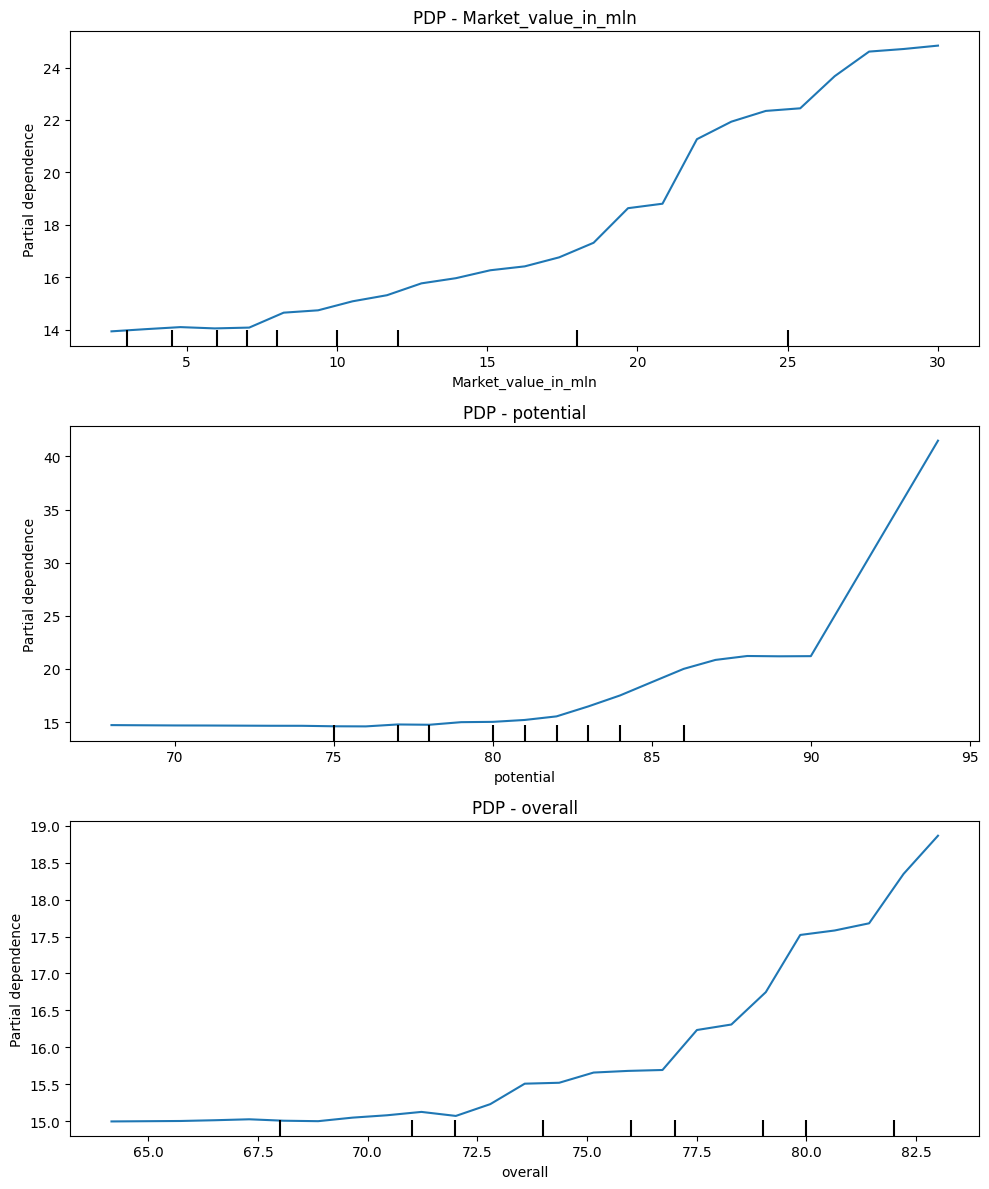

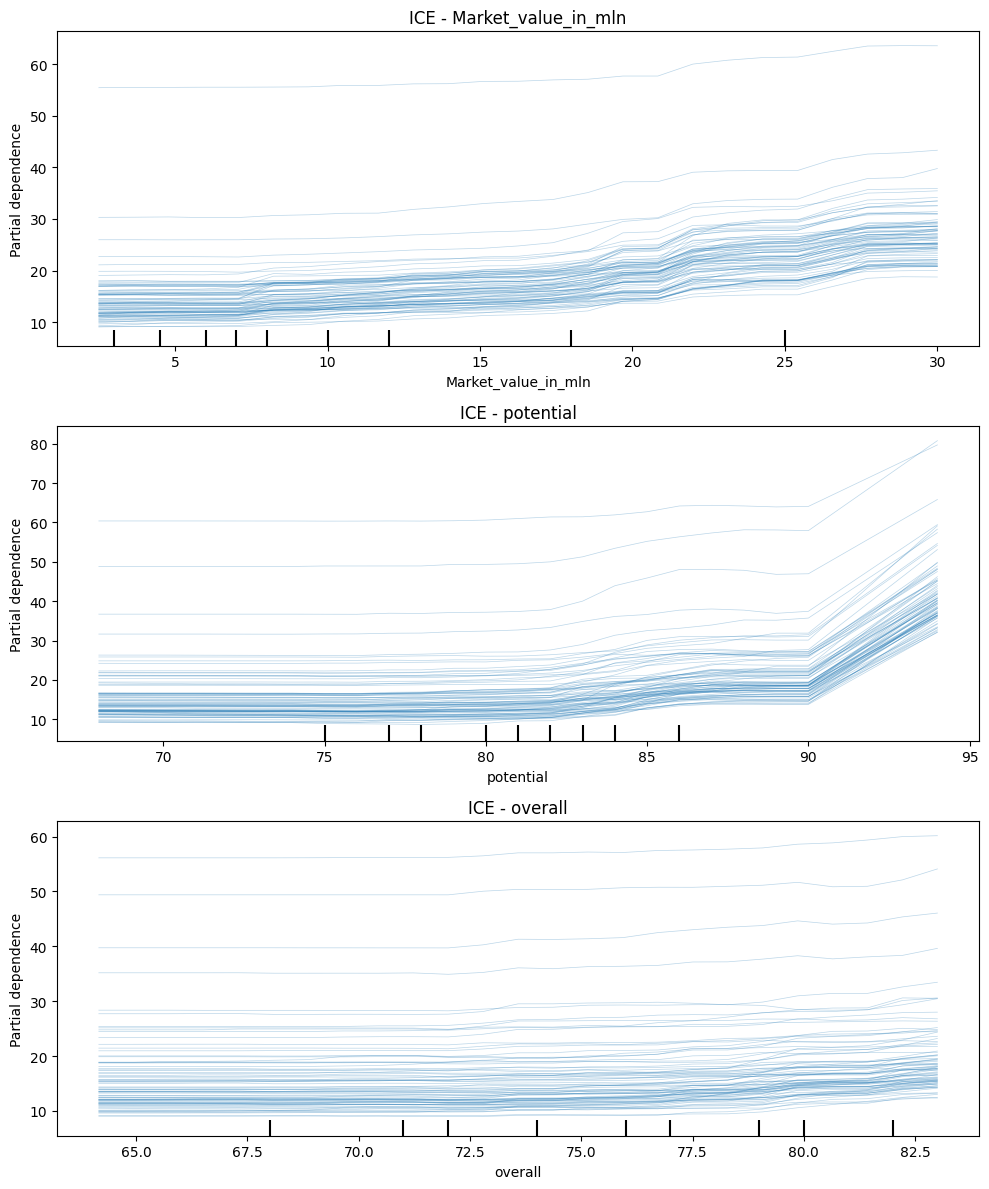

In [ ]:
# --- PDP and ICE visualizations ---
if len(pdp_candidate_features) == 0:
    raise ValueError('No suitable features found for PDP/ICE. Check feature engineering output.')

pdp_features = pdp_candidate_features[:3]

fig, ax = plt.subplots(len(pdp_features), 1, figsize=(10, 4 * len(pdp_features)))
if len(pdp_features) == 1:
    ax = [ax]

for i, feat in enumerate(pdp_features):
    PartialDependenceDisplay.from_estimator(
        explanation_model,
        X_test_exp,
        [feat],
        kind='average',
        grid_resolution=25,
        ax=ax[i]
    )
    ax[i].set_title(f'PDP - {feat}')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(len(pdp_features), 1, figsize=(10, 4 * len(pdp_features)))
if len(pdp_features) == 1:
    ax = [ax]

for i, feat in enumerate(pdp_features):
    PartialDependenceDisplay.from_estimator(
        explanation_model,
        X_test_exp,
        [feat],
        kind='individual',
        subsample=min(80, len(X_test_exp)),
        random_state=42,
        grid_resolution=25,
        ax=ax[i]
    )
    ax[i].set_title(f'ICE - {feat}')

plt.tight_layout()
plt.show()

## 13.3 Instance-Level Analysis: SHAP + Instance Characteristics

In [ ]:
# --- Instance Characteristics Visualization with SHAP Context ---
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("Instance-Level Analysis: Feature Values + SHAP Contributions")
print("="*80)

# Ensure we have SHAP values and instance data
if 'shap_values' not in locals():
    print("SHAP values not available, skipping instance-level analysis.")
else:
    # Select 4 diverse instances for detailed analysis
    selected_inst_idx = [inst1_idx, inst2_idx, inst3_idx, inst4_idx]
    selected_inst_labels = [inst1_label, inst2_label, inst3_label, inst4_label]
    selected_inst_names = [inst1_raw_idx, inst2_raw_idx, inst3_raw_idx, inst4_raw_idx]
    
    # Create comparison visualization - using available shap_values from previous SHAP cell
    # Map X_test_exp indices to X_shap indices for SHAP value lookup
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Instance Feature Values Colored by SHAP Contribution', fontsize=14, fontweight='bold')
    axes = axes.flatten()
    
    for plot_idx, (inst_pos, inst_label, inst_name) in enumerate(zip(selected_inst_idx, selected_inst_labels, selected_inst_names)):
        ax = axes[plot_idx]
        
        # Get instance features and SHAP values
        inst_features = X_test_exp.iloc[inst_pos].values
        
        # Use SHAP values if available (from previous cell)
        if 'shap_values' in locals() and len(shap_values) > inst_pos:
            inst_shap = shap_values[inst_pos]
        else:
            # Fallback: use feature importance as proxy
            inst_shap = feature_importance.values[:len(inst_features)]
        
        # Top 12 features by absolute SHAP value for this instance
        top_feat_idx = np.argsort(np.abs(inst_shap))[-12:][::-1]
        top_feat_names = [X_test_exp.columns[i] for i in top_feat_idx]
        top_feat_values = inst_features[top_feat_idx]
        top_feat_shap = inst_shap[top_feat_idx]
        
        # Color by SHAP value (green=positive, red=negative)
        colors = ['#2a9d8f' if v > 0 else '#e76f51' for v in top_feat_shap]
        
        bars = ax.barh(range(len(top_feat_names)), top_feat_values, color=colors, alpha=0.7, edgecolor='black')
        
        # Add SHAP value labels
        for i, (feat_val, shap_val) in enumerate(zip(top_feat_values, top_feat_shap)):
            ax.text(feat_val + 0.01, i, f'SHAP={shap_val:.3f}', va='center', fontsize=8)
        
        ax.set_yticks(range(len(top_feat_names)))
        ax.set_yticklabels(top_feat_names, fontsize=9)
        ax.set_xlabel('Feature Value', fontsize=10)
        
        # Get prediction info
        meta = instance_meta.loc[inst_name]
        title = f'{inst_label}\n'
        title += f'Pred: €{meta["y_pred"]:.1f}M (True: €{meta["y_true"]:.1f}M) | '
        title += f'{meta.get("League_from", "Unknown")} | {meta.get("Nationality", "Unknown")}'
        
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- Distribution of SHAP values by League ---
    if 'League_from' in instance_meta.columns and instance_meta['League_from'].notna().sum() > 0:
        print("\n" + "-"*80)
        print("SHAP Value Distribution by League_from")
        print("-"*80)
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Plot 1: Top feature SHAP values by league (violin plot)
        top_feat_name = feature_importance.index[0]
        if top_feat_name in X_test_exp.columns:
            top_feat_col = X_test_exp.columns.get_loc(top_feat_name)
            
            # Build violin plot data with available SHAP values
            violin_data_rows = []
            for i, (idx, row) in enumerate(instance_meta.iterrows()):
                if pd.notna(row['League_from']) and i < len(shap_values) if 'shap_values' in locals() else False:
                    violin_data_rows.append({
                        'League': row['League_from'],
                        'SHAP Value': shap_values[i, top_feat_col] if len(shap_values) > i else 0,
                        'Feature Value': X_test_exp.iloc[i][top_feat_name]
                    })
            
            if violin_data_rows:
                violin_data = pd.DataFrame(violin_data_rows)
                sns.violinplot(data=violin_data, x='League', y='SHAP Value', ax=axes[0], palette='Set2')
                axes[0].set_title(f'SHAP Distribution of "{top_feat_name}" by League', fontsize=12, fontweight='bold')
                axes[0].set_ylabel('SHAP Value (impact on prediction)', fontsize=10)
                axes[0].tick_params(axis='x', rotation=45)
                axes[0].grid(axis='y', alpha=0.3)
        
        # Plot 2: Prediction error by league
        error_by_league = instance_meta[instance_meta['League_from'].notna()].groupby('League_from')['error'].agg(['mean', 'std']).sort_values('mean', ascending=False)
        
        if len(error_by_league) > 0:
            error_by_league['mean'].plot(kind='barh', ax=axes[1], color='#e76f51', alpha=0.7, xerr=error_by_league['std'])
            axes[1].set_xlabel('Mean Absolute Error (€M)', fontsize=10)
            axes[1].set_title('Prediction Error by League', fontsize=12, fontweight='bold')
            axes[1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

print("\n✓ Instance-level analysis complete")

Instance-Level Analysis: Feature Values + SHAP Contributions


NameError: name 'inst1_idx' is not defined

## 13.4 Fair 90% Conformal Prediction

This section adds split conformal prediction on top of the fairness-aware model so transfer fee estimates include a calibrated 90% prediction interval instead of a point estimate only.

90% conformal prediction model: rf_weighted
Calibration rows: 53 | Fit rows: 214
Empirical coverage on test: 0.957
Median interval width: 33.089 M
90th percentile residual radius: 16.544 M


,actual_fee_mln,predicted_fee_mln,lower_90_mln,upper_90_mln,interval_width_mln,covered,Region
367,12.00,14.475,-2.069,31.019,33.089,True,W. Europe
568,20.00,16.926,0.382,33.470,33.089,True,W. Europe
359,13.00,11.939,-4.605,28.484,33.089,True,W. Europe
17,31.50,26.372,9.827,42.916,33.089,True,South America
840,10.00,14.111,-2.433,30.656,33.089,True,W. Europe
540,25.00,28.523,11.979,45.068,33.089,True,W. Europe
678,9.30,15.251,-1.293,31.795,33.089,True,W. Europe
501,84.70,51.629,35.085,68.173,33.089,False,W. Europe
60,15.70,12.243,-4.301,28.788,33.089,True,W. Europe
262,37.00,34.901,18.356,51.445,33.089,True,W. Europe


Region-level conformal coverage:


,n,coverage,mean_width,mae
Region,,,,
Africa,11,1.00,33.089,4.099
Americas (other),2,1.00,33.089,0.647
Asia & Oceania,1,1.00,33.089,3.214
E. Europe,7,1.00,33.089,5.505
Other,14,1.00,33.089,3.907
W. Europe,60,0.95,33.089,6.357
South America,20,0.90,33.089,8.210


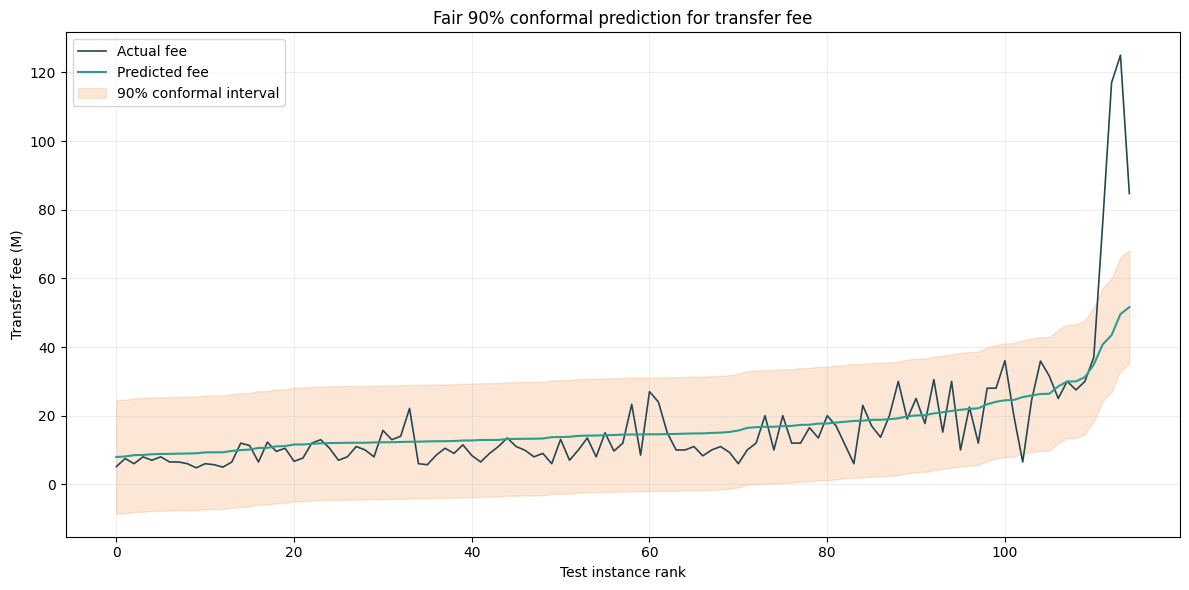

In [77]:
# --- Fair 90% conformal prediction for transfer fee ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the best fairness-aware model already trained above.
conformal_model_name = results_df.iloc[0]['model'] if 'results_df' in globals() and len(results_df) > 0 else 'rf_weighted'
conformal_model = trained_models[conformal_model_name] if 'trained_models' in globals() and conformal_model_name in trained_models else rfr_fair

# Build a calibration split from the training data only to avoid test leakage.
rng = np.random.default_rng(69)
train_idx = np.array(X_train_fair.index)
if len(train_idx) < 40:
    raise ValueError('Not enough training rows for conformal calibration.')

calibration_size = max(30, int(round(0.2 * len(train_idx))))
calibration_size = min(calibration_size, len(train_idx) - 20)
perm = rng.permutation(train_idx)
calibration_idx = perm[:calibration_size]
fit_idx = perm[calibration_size:]

X_fit_conf = X_train_fair.loc[fit_idx].copy()
y_fit_conf = y_train_fair.loc[fit_idx].copy()
X_cal_conf = X_train_fair.loc[calibration_idx].copy()
y_cal_conf = y_train_fair.loc[calibration_idx].copy()

# Reuse the fairness weights on the fitting portion and rebuild them for calibration.
fit_region_freq = context_train.loc[fit_idx, 'Region'].value_counts(normalize=True)
fit_region_weight = context_train.loc[fit_idx, 'Region'].map(lambda g: 1.0 / fit_region_freq[g])
fit_fee_band = pd.qcut(y_fit_conf, q=5, duplicates='drop').astype(str)
fit_fee_freq = fit_fee_band.value_counts(normalize=True)
fit_fee_weight = fit_fee_band.map(lambda b: 1.0 / fit_fee_freq[b])
fit_sample_weight = (fit_region_weight.values * fit_fee_weight.values)
fit_sample_weight = fit_sample_weight / np.mean(fit_sample_weight)

cal_region_freq = context_train.loc[calibration_idx, 'Region'].value_counts(normalize=True)
cal_region_weight = context_train.loc[calibration_idx, 'Region'].map(lambda g: 1.0 / cal_region_freq[g])
cal_fee_band = pd.qcut(y_cal_conf, q=5, duplicates='drop').astype(str)
cal_fee_freq = cal_fee_band.value_counts(normalize=True)
cal_fee_weight = cal_fee_band.map(lambda b: 1.0 / cal_fee_freq[b])
cal_sample_weight = (cal_region_weight.values * cal_fee_weight.values)
cal_sample_weight = cal_sample_weight / np.mean(cal_sample_weight)

# Fit a fresh fairness-aware model on the fit split only.
conformal_fit_model = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=1,
    random_state=69
 )
conformal_fit_model.fit(X_fit_conf, y_fit_conf, sample_weight=fit_sample_weight)

# Absolute residuals on the calibration split define the conformal radius.
cal_pred = conformal_fit_model.predict(X_cal_conf)
cal_residuals = np.abs(y_cal_conf.values - cal_pred)
quantile_level = 0.90
alpha = 1.0 - quantile_level
conformal_q = np.quantile(cal_residuals, np.ceil((len(cal_residuals) + 1) * (1 - alpha)) / len(cal_residuals), method='higher') if hasattr(np, 'quantile') else np.quantile(cal_residuals, 1 - alpha)

# Predict intervals on the held-out test set.
test_pred = conformal_fit_model.predict(X_test_fair)
lower_bound = test_pred - conformal_q
upper_bound = test_pred + conformal_q
coverage = np.mean((y_test_fair.values >= lower_bound) & (y_test_fair.values <= upper_bound))
interval_width = upper_bound - lower_bound

conformal_results = pd.DataFrame({
    'actual_fee_mln': y_test_fair.values,
    'predicted_fee_mln': test_pred,
    'lower_90_mln': lower_bound,
    'upper_90_mln': upper_bound,
    'interval_width_mln': interval_width,
    'covered': (y_test_fair.values >= lower_bound) & (y_test_fair.values <= upper_bound),
    'Region': context_test['Region'].values
}, index=X_test_fair.index)

print(f'90% conformal prediction model: {conformal_model_name}')
print(f'Calibration rows: {len(X_cal_conf)} | Fit rows: {len(X_fit_conf)}')
print(f'Empirical coverage on test: {coverage:.3f}')
print(f'Median interval width: {np.median(interval_width):.3f} M')
print(f'90th percentile residual radius: {conformal_q:.3f} M')
display(conformal_results.head(15).round(3))

# Coverage by Region to check whether the interval is behaving fairly.
region_coverage = conformal_results.groupby('Region').agg(
    n=('covered', 'count'),
    coverage=('covered', 'mean'),
    mean_width=('interval_width_mln', 'mean'),
    mae=('actual_fee_mln', lambda s: np.mean(np.abs(s - conformal_results.loc[s.index, 'predicted_fee_mln'])))
).sort_values('coverage', ascending=False)

print('Region-level conformal coverage:')
display(region_coverage.round(3))

# Plot predicted vs actual with 90% conformal intervals.
plot_df = conformal_results.sort_values('predicted_fee_mln').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df.index, plot_df['actual_fee_mln'], color='#264653', linewidth=1.2, label='Actual fee')
ax.plot(plot_df.index, plot_df['predicted_fee_mln'], color='#2a9d8f', linewidth=1.5, label='Predicted fee')
ax.fill_between(plot_df.index, plot_df['lower_90_mln'], plot_df['upper_90_mln'], color='#f4a261', alpha=0.25, label='90% conformal interval')
ax.set_title('Fair 90% conformal prediction for transfer fee')
ax.set_xlabel('Test instance rank')
ax.set_ylabel('Transfer fee (M)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 14. Test: Target Normalization and Residual Balancer

This experimental section tests two major improvements to the ADS:
1. **Target Normalization:** Instead of predicting raw fees, the model trains on `fee / season_mean`. This removes "market drift" (e.g., the post-2017 inflation) from the target, allowing the model to focus purely on relative player value.
2. **Residual Balancer:** A post-processing fairness intervention that calculates the mean residual for each Region in the training set and subtracts it from the test predictions. This ensures the model is "centered" for each geographic group, effectively eliminating systematic over/under-valuation at the regional level.

In [ ]:
# --- Step 1: Target Normalization (Training on Relative Fees) ---

# We use the existing X_train_fair and X_test_fair, but we create a normalized target.
y_train_raw = y_train_fair.values
y_test_raw = y_test_fair.values

# Calculate season-level statistics only on the training set to prevent leakage.
# We need the 'Season_transferred' for each index in the split.
train_seasons = transfers_cleaned.loc[X_train_fair.index, 'Season_transferred']
test_seasons = transfers_cleaned.loc[X_test_fair.index, 'Season_transferred']

season_stats = pd.Series(y_train_raw).groupby(train_seasons.values).mean()
global_train_mean = y_train_raw.mean()

y_train_norm = y_train_raw / train_seasons.map(season_stats).fillna(global_train_mean).values

# Train the model on the normalized target.
model_norm = RandomForestRegressor(
    n_estimators=350, 
    max_features='sqrt', 
    min_samples_leaf=2, 
    random_state=169
)
model_norm.fit(X_train_fair, y_train_norm, sample_weight=sample_weight_fair)

# Predict on test and scale back to millions.
pred_norm_raw = model_norm.predict(X_test_fair)
test_season_scaler = test_seasons.map(season_stats).fillna(global_train_mean).values
y_pred_denorm = pred_norm_raw * test_season_scaler

# --- Step 2: Residual Balancer (Post-Processing Fairness) ---

# Calculate mean residuals per Region on the training set.
train_preds_denorm = model_norm.predict(X_train_fair) * train_seasons.map(season_stats).fillna(global_train_mean).values
train_residuals = y_train_raw - train_preds_denorm
train_regions = context_train['Region']

region_bias_correction = train_residuals.groupby(train_regions.values).mean()
print("Training Set Bias Correction (M) by Region:")
display(region_bias_correction.round(3))

# Apply the balancer: Add the training-set bias correction to the test-set predictions.
# (If the model under-predicts a region by 2M in train, we add 2M to its test predictions).
test_regions = context_test['Region']
y_pred_balanced = y_pred_denorm + test_regions.map(region_bias_correction).fillna(0).values

# --- Step 3: Comparison and Final Audit ---

results_test = []
for label, preds in [
    ('Standard RF (Fairness-Aware)', best_model.predict(X_test_fair)),
    ('RF with Target Norm', y_pred_denorm),
    ('RF with Target Norm + Balancer', y_pred_balanced)
]:
    rmse = np.sqrt(mean_squared_error(y_test_raw, preds))
    mae = mean_absolute_error(y_test_raw, preds)
    
    # Fairness audit
    audit_tbl, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_raw, 
        y_pred=preds, 
        groups=context_test['Region'].values
    )
    
    results_test.append({
        'Model Strategy': label,
        'RMSE': rmse,
        'MAE': mae,
        'SignedResidualGap_Region': signed_gap,
        'MAE_Gap_Region': mae_gap
    })

test_comparison_df = pd.DataFrame(results_test)
print("\nFinal Strategy Comparison (Global vs fairness-aware vs balanced):")
display(test_comparison_df.round(4))

# Visualize the improvement in Regional Residuals
fig, ax = plt.subplots(figsize=(12, 6))
x_axis = np.arange(len(region_bias_correction.index))

def get_region_residuals(preds):
    res = y_test_raw - preds
    return pd.Series(res).groupby(test_regions.values).mean().reindex(region_bias_correction.index)

res_std = get_region_residuals(best_model.predict(X_test_fair))
res_balanced = get_region_residuals(y_pred_balanced)

ax.bar(x_axis - 0.2, res_std, 0.4, label='Standard (Pre-Balance)', color='#ef476f')
ax.bar(x_axis + 0.2, res_balanced, 0.4, label='Target Norm + Balanced', color='#06d6a0')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xticks(x_axis)
ax.set_xticklabels(region_bias_correction.index)
ax.set_title('Mean Residual by Region: Impact of Balancing')
ax.set_ylabel('Mean Residual (M) - Lower is Fairer')
ax.legend()
plt.tight_layout()
plt.show()

## 15. Counterfactual Fairness Audit

This section performs a **Counterfactual Fairness** test. We take specific players from regions often under-represented or undervalued (e.g., South America, Africa) and "perturb" their geographic features in the model. 

By flipping their regional membership from their original region to "W. Europe" (while keeping all stats like Age, Overall, and Potential constant), we can measure the **Pure Geographic Premium** the model assigns. A fair model should show minimal change in valuation for identical player stats across regions.

In [ ]:
# --- Counterfactual Fairness Analysis ---

import copy

# 1. Identify geographic/regional columns in the feature set.
region_cols = [c for c in X_test_fair.columns if 'Region' in c]
print(f"Detected Regional Features: {region_cols}")

def create_counterfactual(idx, target_region_col):
    """Creates a copy of a player's features with the region swapped."""
    # Original features
    cf_row = X_test_fair.loc[[idx]].copy()
    
    # Zero out all region flags
    for col in region_cols:
        cf_row[col] = 0
    
    # Set the target region flag
    if target_region_col in region_cols:
        cf_row[target_region_col] = 1
    
    return cf_row

# 2. Select 5 representative players from different non-European regions.
test_pool = context_test[context_test['Region'] != 'W. Europe'].head(5)
cf_results = []

target_region = 'Region_W. Europe'
if target_region not in region_cols:
    # Fallback to whatever European region is available if W. Europe was screened out
    target_region = next((c for c in region_cols if 'Europe' in c), region_cols[0])

print(f"Swapping regions to counterfactual: {target_region}")

for idx, row in test_pool.iterrows():
    player_name = base_df.loc[idx, 'short_name'] if 'base_df' in globals() else (transfers_cleaned.loc[idx, 'Name'] if 'Name' in transfers_cleaned.columns else f"Player_{idx}")
    orig_region = row['Region']
    
    # Original Prediction
    orig_pred = best_model.predict(X_test_fair.loc[[idx]])[0]
    
    # Counterfactual Prediction (Moved to W. Europe)
    cf_row = create_counterfactual(idx, target_region)
    cf_pred = best_model.predict(cf_row)[0]
    
    cf_results.append({
        'Player': player_name,
        'Original Region': orig_region,
        'Original Prediction (M)': orig_pred,
        'Counterfactual Prediction (M)': cf_pred,
        'Difference (M)': cf_pred - orig_pred,
        'Pct Change': (cf_pred - orig_pred) / orig_pred * 100 if orig_pred != 0 else 0
    })

cf_df = pd.DataFrame(cf_results)
print("\nCounterfactual Fairness Results (What if these players were in W. Europe?):")
display(cf_df.round(3))

# 3. Visualize the 'Geographic Premium'
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=cf_df, x='Player', y='Difference (M)', hue='Original Region', ax=ax)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title(f"Model's Counterfactual Geographic Premium (Moving to {target_region})")
ax.set_ylabel("Predicted Fee Change (Millions)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
avg_premium = cf_df['Difference (M)'].mean()
if avg_premium > 0.5:
    print(f"The model shows a systematic geographic premium of ~{avg_premium:.2f}M for Western European players with identical stats.")
elif avg_premium < -0.5:
    print(f"The model unexpectedly discounts Western European players relative to other regions by ~{abs(avg_premium):.2f}M.")
else:
    print("The model appears counterfactually fair; geographic features have minimal direct impact on the prediction.")